# 📞 Stage 2 — Probability & Distributions
## Call Center Volume Prediction — Telecom Analytics

---

> **Business Problem:** A telecom call center wants to predict staffing needs.  
> When will call volumes spike? What is the probability of receiving 50+ calls in an hour?  
> How many agents should be on duty at each shift?

> 📌 **Tamil:** "Probability என்பது ஒரு event நடக்கும் வாய்ப்பு. Distribution என்பது data எந்த pattern-ல் distribute ஆகிறது. CLT(Central Limit Theorem) என்பது statistics-இன் foundation — இதை இந்த project-ல் learn பண்ணுவோம்."

---

### 🗂️ What We Will Cover

| Step | Concept | Application |
|------|---------|-------------|
| 1 | Setup & Dataset | 6-month hourly call logs |
| 2 | Exploratory Analysis | Patterns by hour, day, shift |
| 3 | Poisson Distribution | Model count data (calls/hour) |
| 4 | Normal Distribution | Continuous variables (call duration) |
| 5 | Binomial Distribution | Success/failure (calls resolved?) |
| 6 | Central Limit Theorem | Why sample means normalize |
| 7 | Z-scores | Standardize, detect anomalies |
| 8 | Sampling Methods | Random, stratified, systematic |
| 9 | Probability Calculations | Staffing decisions |
| 10 | Business Dashboard | All insights in one view |

---

## ⚙️ Step 0 — Imports & Color Palette

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import poisson, norm, binom, expon
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Color palette ──
PURPLE = '#534AB7'
TEAL   = '#0F6E56'
AMBER  = '#BA7517'
CORAL  = '#993C1D'
BLUE   = '#185FA5'
LGRAY  = '#F1EFE8'
DGRAY  = '#5F5E5A'
COLORS = [PURPLE, TEAL, AMBER, CORAL, BLUE, DGRAY]

plt.rcParams.update({
    'figure.facecolor': '#FAFAFA',
    'axes.facecolor':   '#FFFFFF',
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linestyle': '--',
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False, 'axes.spines.right': False,
})
print("✅ Libraries loaded!")

✅ Libraries loaded!


---
## 🗄️ Step 0b — Generate Dataset (6-Month Call Center Logs)

We simulate **4,320 rows** of hourly call data across 6 months with:
- Realistic **time-of-day patterns** (peak hours 10am, 2pm)
- **Weekday vs weekend** volume difference
- **Month-over-month growth trend** (+15%)
- Poisson-distributed call arrivals (industry standard model)
- Binomial outcomes: calls abandoned, calls resolved

> 📌 **Tamil:** "Real call center data போல் synthetic dataset create பண்றோம் — Poisson process use பண்றோம் (call arrivals always follow Poisson)."


In [6]:
np.random.seed(42)
days  = 180   # 6 months
records = []

hour_mult_map = {
    0:0.30, 1:0.20, 2:0.15, 3:0.12, 4:0.15, 5:0.30,
    6:0.70, 7:1.10, 8:1.50, 9:1.80,10:2.10,11:2.00,
   12:1.60,13:1.70,14:2.00,15:1.90,16:1.70,17:1.40,
   18:1.10,19:0.90,20:0.70,21:0.60,22:0.50,23:0.40
}

for day in range(days):
    dow = day % 7
    for hour in range(24):
        dow_mult   = 0.55 if dow >= 5 else 1.0
        trend      = 1 + (day / days) * 0.15
        lam        = max(1, 28 * hour_mult_map[hour] * dow_mult * trend)
        calls      = np.random.poisson(lam)
        abandoned  = np.random.binomial(calls, 0.08) if calls > 0 else 0
        resolved   = np.random.binomial(max(0, calls-abandoned), 0.87) if calls-abandoned > 0 else 0
        duration   = np.random.exponential(4.5, calls).sum().round(1) if calls > 0 else 0.0
        wait       = max(0, np.random.exponential(2.2 * hour_mult_map[hour])) if calls > 0 else 0

        shift = ('Night' if hour < 6 else
                 'Morning' if hour < 14 else
                 'Evening' if hour < 20 else 'Night')

        records.append({
            'date':                  pd.Timestamp('2024-01-01') + pd.Timedelta(days=day),
            'day_of_week':           ['Mon','Tue','Wed','Thu','Fri','Sat','Sun'][dow],
            'is_weekend':            dow >= 5,
            'hour':                  hour,
            'shift':                 shift,
            'calls_received':        calls,
            'calls_abandoned':       abandoned,
            'calls_resolved':        resolved,
            'total_call_duration_min': round(duration, 1),
            'avg_wait_time_min':     round(wait, 2),
            'base_lambda':           round(lam, 2),
        })

df = pd.DataFrame(records)
df['abandon_rate']     = (df['calls_abandoned'] / df['calls_received'].clip(1)).round(3)
df['resolution_rate']  = (df['calls_resolved']  / df['calls_received'].clip(1)).round(3)

# df.to_csv('callcenter_logs.csv', index=False)
# print(f"✅ Dataset: {len(df):,} rows × {df.shape[1]} columns")

df = pd.read_csv('callcenter_logs.csv')
print(f"✅ Dataset created: {len(df):,} rows × {df.shape[1]} columns")
df.head(10)

✅ Dataset created: 4,320 rows × 13 columns


,date,day_of_week,is_weekend,hour,shift,calls_received,calls_abandoned,calls_resolved,total_call_duration_min,avg_wait_time_min,base_lambda,abandon_rate,resolution_rate
0,1/1/2024,Mon,False,0,Night,6,1,4,31.4,0.13,8.40,0.167,0.667
1,1/1/2024,Mon,False,1,Night,5,0,5,18.0,0.02,5.60,0.000,1.000
2,1/1/2024,Mon,False,2,Night,2,1,0,9.1,0.03,4.20,0.500,0.000
3,1/1/2024,Mon,False,3,Night,3,0,2,7.9,0.19,3.36,0.000,0.667
4,1/1/2024,Mon,False,4,Night,8,0,8,21.0,0.53,4.20,0.000,1.000
5,1/1/2024,Mon,False,5,Night,4,1,2,14.9,0.08,8.40,0.250,0.500
6,1/1/2024,Mon,False,6,Morning,25,1,23,90.6,0.12,19.60,0.040,0.920
7,1/1/2024,Mon,False,7,Morning,27,4,19,141.1,0.70,30.80,0.148,0.704
8,1/1/2024,Mon,False,8,Morning,42,2,38,170.3,2.49,42.00,0.048,0.905
9,1/1/2024,Mon,False,9,Morning,45,6,31,182.6,4.11,50.40,0.133,0.689


---
## 📋 Step 1 — Exploratory Data Analysis

Before fitting any distribution, understand the raw data patterns.

> 📌 **Tamil:** "EDA = data-ஐ explore பண்றது — patterns, trends, anomalies கண்டுபிடிக்கிறது."


In [7]:
print("=" * 55)
print("  DATASET OVERVIEW")
print("=" * 55)
print(f"  Rows    : {df.shape[0]:,}")
print(f"  Columns : {df.shape[1]}")
df['date'] = pd.to_datetime(df['date']) # Convert to datetime
print(f"  Date range: {df['date'].min().date()} → {df['date'].max().date()}")
print()
print(df[['calls_received','calls_abandoned','calls_resolved',
          'avg_wait_time_min','abandon_rate']].describe().round(2))

  DATASET OVERVIEW
  Rows    : 4,320
  Columns : 13
  Date range: 2024-01-01 → 2024-06-28

       calls_received  calls_abandoned  calls_resolved  avg_wait_time_min  \
count         4320.00          4320.00         4320.00            4320.00   
mean            27.47             2.21           21.99               2.28   
std             20.50             2.17           16.57               3.01   
min              0.00             0.00            0.00               0.00   
25%              9.00             0.00            7.00               0.35   
50%             23.00             2.00           18.00               1.10   
75%             44.00             3.00           35.00               2.99   
max             86.00            14.00           72.00              28.87   

       abandon_rate  
count       4320.00  
mean           0.08  
std            0.09  
min            0.00  
25%            0.00  
50%            0.07  
75%            0.11  
max            1.00  


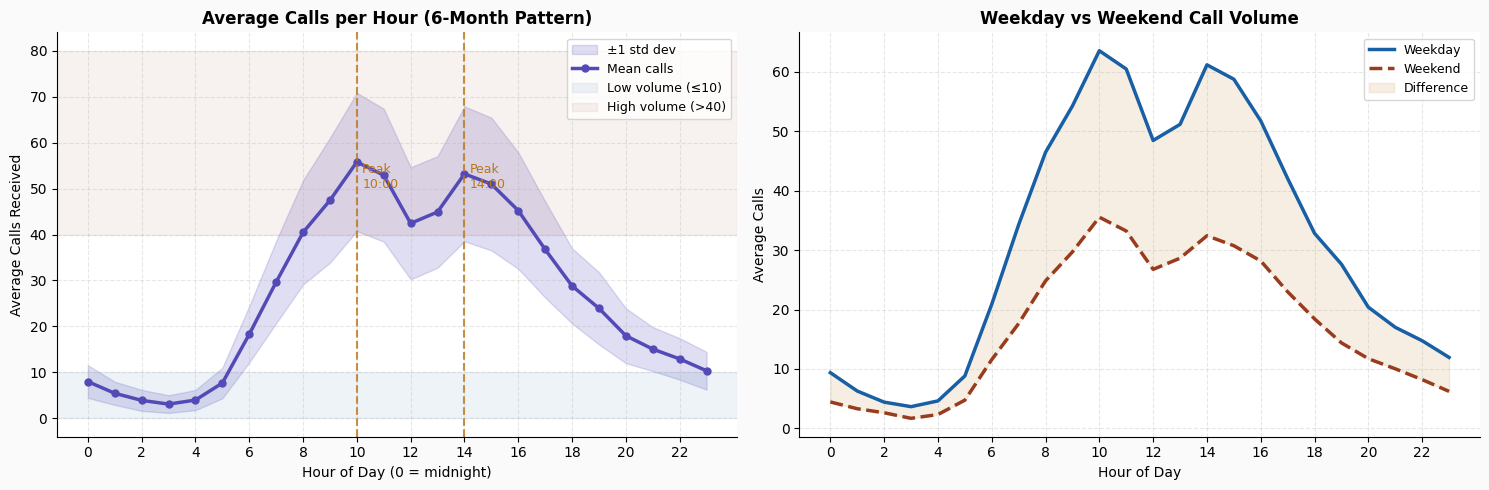


Peak hour (weekday): 10:00  — avg 63.6 calls
Peak hour (weekend): 10:00  — avg 35.5 calls
Weekend volume is ~46% lower than weekday


In [29]:
# 👉 ஒரு call center / customer support system-ல எந்த நேரத்தில் அதிக calls வருது? 
# Weekend vs Weekday எப்படி வேறுபடுது? என்று analyze பண்ணுது.

# | Hour  | calls_received |
# | ----- | --------- |
# | 9 AM  | 25        |
# | 10 AM | 52        |
# | 11 AM | 48        |


# 👉 அந்த hour-ல calls எவ்வளவு vary ஆகுது?
# small std → stable calls
# high std → unpredictable calls

# Hourly call pattern — the most important EDA view
hourly_avg = df.groupby('hour')['calls_received'].mean()  #ஒவ்வொரு hour-க்கும்: average calls calculate பண்ணுது
hourly_std = df.groupby('hour')['calls_received'].std()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# | Left           | Right              |
# | -------------- | ------------------ |
# | Hourly pattern | Weekday vs Weekend |

# Left: hourly pattern with error band - Mean ± Standard Deviation
axes[0].fill_between(hourly_avg.index, 
                     hourly_avg - hourly_std,  # Lower bound 
                     hourly_avg + hourly_std, # Upper bound
                     color=PURPLE, alpha=0.18, label='±1 std dev')
axes[0].plot(hourly_avg.index, 
             hourly_avg.values, color=PURPLE, linewidth=2.5, marker='o', markersize=5, label='Mean calls')

# | Calls | Frequency  |
# | ----- | ---------- |
# | 0–10  | very quiet |
# | 10–30 | normal     |
# | 40+   | very busy  |

# 0–10, 40–80 👉 fixed statistical rule இல்லை ❌

axes[0].axhspan(0, 10, color=BLUE, alpha=0.07, label='Low volume (≤10)')
axes[0].axhspan(40, 80, color=CORAL, alpha=0.07, label='High volume (>40)')
for peak_h in [10, 14]:
    axes[0].axvline(peak_h, color=AMBER, linestyle='--', linewidth=1.5, alpha=0.8)
    axes[0].text(peak_h+0.2, hourly_avg.max()*0.9, f'Peak\n{peak_h}:00',
                 color=AMBER, fontsize=9)
axes[0].set_title('Average Calls per Hour (6-Month Pattern)', fontweight='bold')
axes[0].set_xlabel('Hour of Day (0 = midnight)')
axes[0].set_ylabel('Average Calls Received')
axes[0].set_xticks(range(0,24,2))
axes[0].legend(fontsize=9)

# Right: Weekday vs Weekend
wd_avg = df.groupby(['hour','is_weekend'])['calls_received'].mean().unstack()
axes[1].plot(wd_avg.index, wd_avg[False], color=BLUE,  linewidth=2.5, label='Weekday') # False → Weekday
axes[1].plot(wd_avg.index, wd_avg[True],  color=CORAL, linewidth=2.5, linestyle='--', label='Weekend') # True → Weekend
axes[1].fill_between(wd_avg.index, wd_avg[False], wd_avg[True],alpha=0.12, color=AMBER, label='Difference') 
axes[1].set_title('Weekday vs Weekend Call Volume', fontweight='bold')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Average Calls')
axes[1].set_xticks(range(0,24,2))
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f"\nPeak hour (weekday): {wd_avg[False].idxmax()}:00  "  #highest weekday call hour
      f"— avg {wd_avg[False].max():.1f} calls")  
print(f"Peak hour (weekend): {wd_avg[True].idxmax()}:00  " #highest weekend call hour
      f"— avg {wd_avg[True].max():.1f} calls")
# “Weekend calls, weekday calls-ஐ விட எத்தனை % குறைவு?”
# How 46% came? - Average of all 24 weekend hours vs Average of all 24 weekday hours
print(f"Weekend volume is ~{(1-wd_avg[True].mean()/wd_avg[False].mean())*100:.0f}% lower than weekday")

---
## 🎯 Step 2 — Poisson Distribution (Count Data)

> 📌 **Tamil:** "Poisson distribution = ஒரு fixed time period-ல் எத்தனை events நடக்கும் என்று model பண்றது. Call center-ல் calls/hour, website-ல் clicks/minute — எல்லாம் Poisson."

### When to use Poisson? 
- You are **counting events** in a fixed time/space interval - randomly வரும்
- Events are **independent** of each other - independent இருக்கும்
- **Average rate (λ)** is constant - average rate almost same இருக்கும்

### Formula
```
P(X = k) = (e^−λ × λ^k) / k!
```
| Symbol     | Meaning               |
| ---------- | --------------------- |
| X          | number of events      |
| k          | exact count           |
| λ (lambda) | average events        |
| e          | mathematical constant |
| k!         | factorial             |

**λ (lambda)** = average number of events per interval

### Real Examples
| Scenario | λ (lambda) |
|----------|-----------|
| Calls per hour at 10am | ~58 |
| Website hits per minute | ~200 |
| Customer arrivals per hour | ~45 |
| Defects per 1000 units | ~3 |


In [ ]:
# 👉 “ஒரு fixed நேரத்தில் எத்தனை calls / clicks / customers வரும்?” question: 10 AM நேரத்தில் average எத்தனை calls வரும்?

# 10 AM: 55 calls average
# சில நாள்: 50, 58, 62, 53, 57
# 👉 இதை Poisson model handle பண்ணும்.

# Day	    Calls
# Monday	55
# Tuesday	60
# Wednesday	58

# Average:
# λ= 55+60+58/3 =57.7

# Focus on peak hour (10am, weekday) data , calls_received
peak_data = df[(df['hour'] == 10) & (~df['is_weekend'])]['calls_received']
lambda_hat = peak_data.mean()  # MLE estimate of λ

print("── Poisson Distribution — 10:00am Weekday Calls ──")
print(f"  Observed data points : {len(peak_data)}") #10 AM weekday data 130 times collect பண்ணியிருக்கிறோம்.
print(f"  Estimated λ (mean)   : {lambda_hat:.2f} calls/hour") # Average calls per hour At 10 AM: Average ≈ 64 calls/hour
print(f"  Variance             : {peak_data.var():.2f}  (should ≈ λ for Poisson)") # Variance = spread 👉 calls daily எப்படி change ஆகுது?
print(f"  Std Dev              : {peak_data.std():.2f}") # Poisson distribution-ல standard deviation, mean-க்கு square root ஆகும். 
print()

# 👉 “Threshold (40, 50, 60, 70, 80) random ஆ?”
# ❌ இல்லை — random இல்லை
# ✔️ அது business decision + probability cut-off based
# Threshold எப்படி தேர்வு செய்றாங்க? இது 3 விஷயங்களிலிருந்து வருகிறது:
# normal workload
# peak handling
# SLA (service level agreement) - SLA என்பது ஒரு சேவை வழங்கும் நிறுவனம் (company) மற்றும் வாடிக்கையாளர் இடையிலான ஒரு ஒப்பந்தம்.
# சேவை எவ்வளவு வேகமாக வழங்க வேண்டும்
# எவ்வளவு நேரத்தில் பிரச்சனை சரி செய்ய வேண்டும்
# சேவை தரம் (quality) எப்படி இருக்க வேண்டும்

# ஒரு call center SLA:

# 80% calls 30 விநாடிக்குள் attend செய்ய வேண்டும்
# complaint 24 மணி நேரத்துக்குள் resolve செய்ய வேண்டும்

# 👉 இது “நாங்கள் இந்த அளவுக்கு service தருவோம்”ன்னு உறுதி செய்யும் agreement.

# | Level | Meaning           |
# | ----- | ----------------- |
# | 40    | very low baseline |
# | 50    | light expectation |
# | 60    | normal workload   |
# | 70    | busy day          |
# | 80    | extreme peak      |


# Key probability calculations for staffing - Poisson Distribution (call center calls/hour)
for threshold in [40, 50, 60, 70, 80]:
    p_exceed = 1 - poisson.cdf(threshold, mu=lambda_hat) # CDF means cumulative probability
    p_below  = poisson.cdf(threshold, mu=lambda_hat)
    print(f"  P(calls > {threshold}) = {p_exceed:.4f} = {p_exceed*100:.2f}%  "
          f"| P(calls ≤ {threshold}) = {p_below:.4f}")

print()
print(f"  ► STAFFING INSIGHT:")
print(f"    If each agent handles 8 calls/hour,")
print(f"    you need at least {int(np.ceil(lambda_hat/8))} agents at 10am peak.")
print(f"    For 95% SLA coverage: {int(np.ceil(poisson.ppf(0.95, lambda_hat)/8))} agents")

── Poisson Distribution — 10:00am Weekday Calls ──
  Observed data points : 130
  Estimated λ (mean)   : 63.57 calls/hour
  Variance             : 79.29  (should ≈ λ for Poisson)
  Std Dev              : 8.90

  P(calls > 40) = 0.9990 = 99.90%  | P(calls ≤ 40) = 0.0010
  P(calls > 50) = 0.9534 = 95.34%  | P(calls ≤ 50) = 0.0466
  P(calls > 60) = 0.6432 = 64.32%  | P(calls ≤ 60) = 0.3568
  P(calls > 70) = 0.1909 = 19.09%  | P(calls ≤ 70) = 0.8091
  P(calls > 80) = 0.0198 = 1.98%  | P(calls ≤ 80) = 0.9802

  ► STAFFING INSIGHT:
    If each agent handles 8 calls/hour,
    you need at least 8 agents at 10am peak.
    For 95% SLA coverage: 10 agents


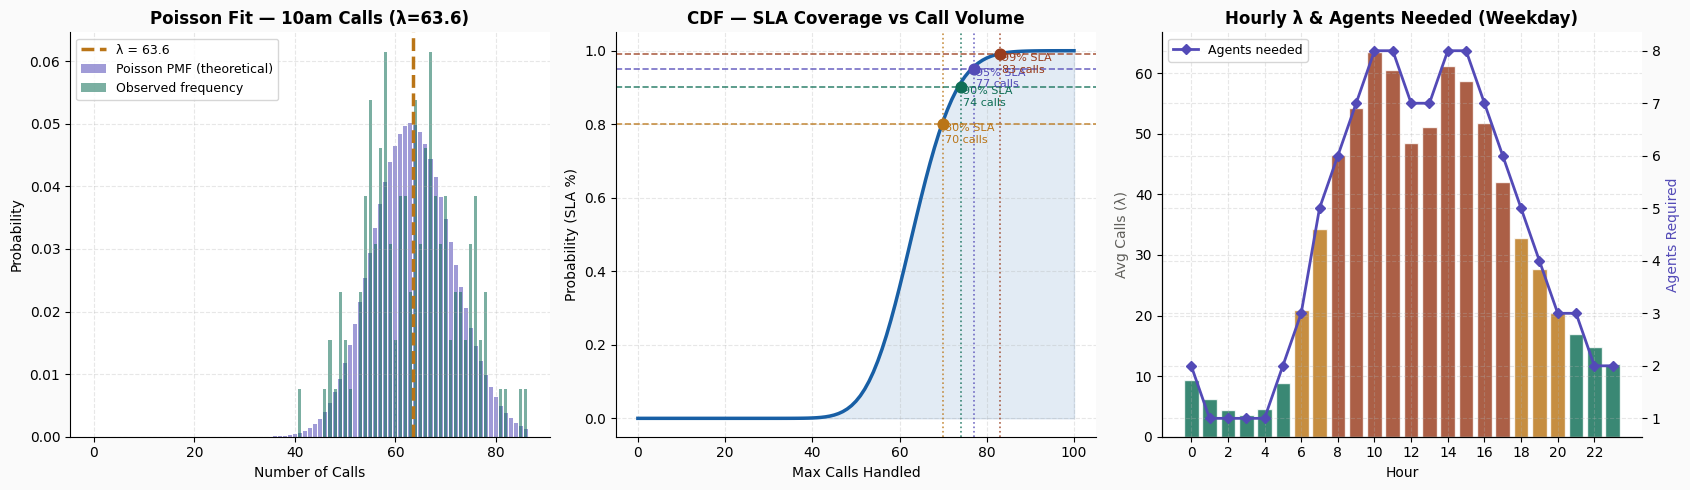

In [11]:
# 👉 “ஒரு hour-ல எத்தனை calls வரும்?”
# 👉 “Poisson model சரியா fit ஆகுதா?”
# 👉 “எத்தனை agents தேவை?”
# 👉 “SLA (80%, 90%, 95%) எப்படி satisfy பண்ணுவது?”

# Visual: Poisson fit to actual data
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# 1. Observed vs Poisson PMF - இந்த plot 2 விஷயங்களை compare பண்ணுது:

# 🔵 Theoretical (Poisson PMF)
# 👉 Model சொல்லுது: λ (average calls) = ~63 அதனால் 60–65 calls அதிகம் வரும் probability

# 🟢 Actual Data (Observed frequency)
# 👉 real data-ல:உண்மையில எவ்வளவு calls வந்தது

# 👉 If both bars overlap well: ✔️ Poisson model correct
# 👉 If mismatch: ❌ data not Poisson (maybe seasonality / spikes)

k_vals  = np.arange(0, int(peak_data.max()) + 1)
poisson_pmf = poisson.pmf(k_vals, mu=lambda_hat)
observed_freq = peak_data.value_counts(normalize=True).sort_index()

axes[0].bar(k_vals, poisson_pmf, color=PURPLE, alpha=0.55, label='Poisson PMF (theoretical)')
axes[0].bar(observed_freq.index, observed_freq.values,
            color=TEAL, alpha=0.55, width=0.6, label='Observed frequency')
axes[0].axvline(lambda_hat, color=AMBER, linewidth=2.5,
                linestyle='--', label=f'λ = {lambda_hat:.1f}')
axes[0].set_title(f'Poisson Fit — 10am Calls (λ={lambda_hat:.1f})', fontweight='bold')
axes[0].set_xlabel('Number of Calls'); axes[0].set_ylabel('Probability')
axes[0].legend(fontsize=9)

# 2. CDF — probability of handling calls with n agents
# | SLA | Meaning                        |
# | --- | ------------------------------ |
# | 80% | 80% calls handle பண்ண முடியும் |
# | 90% | 90% coverage                   |
# | 95% | high reliability               |
# | 99% | extreme safety                 |

# இந்த agents இருந்தா இவ்வளவு calls-க்கு guarantee service தரலாம்
# 95% SLA → maybe 78 calls
# 👉 meaning: 95% days calls ≤ 78

k_range  = np.arange(0, 101)
cdf_vals = poisson.cdf(k_range, mu=lambda_hat)
axes[1].plot(k_range, cdf_vals, color=BLUE, linewidth=2.5)
axes[1].fill_between(k_range, cdf_vals, alpha=0.12, color=BLUE)
for sla, col in [(0.80,AMBER),(0.90,TEAL),(0.95,PURPLE),(0.99,CORAL)]:
    k_sla = int(poisson.ppf(sla, mu=lambda_hat))
    axes[1].axhline(sla, color=col, linestyle='--', linewidth=1.2, alpha=0.8)
    axes[1].axvline(k_sla, color=col, linestyle=':', linewidth=1.2, alpha=0.8)
    axes[1].scatter([k_sla],[sla], s=60, color=col, zorder=5)
    axes[1].text(k_sla+0.5, sla-0.05, f'{int(sla*100)}% SLA\n{k_sla} calls',
                 fontsize=8, color=col)
axes[1].set_title('CDF — SLA Coverage vs Call Volume', fontweight='bold')
axes[1].set_xlabel('Max Calls Handled'); axes[1].set_ylabel('Probability (SLA %)')

# 3. λ across different hours (staffing guide)
# 🔹 hourly_lambda = average calls per hour
# Hour	λ (avg calls)
# 10AM	63
# 11AM	55
# 2PM	30

# 👉 Agents formula: agents_needed = λ / 8

# 👉 because: 1 agent = 8 calls/hour
# 🧠 Tamil meaning: 👉 “ஒரு hour-ல வரும் calls-ஐ handle பண்ண எத்தனை agents வேணும்?”

# 📊 Example: λ = 64 calls, each agent = 8 calls
# 👉 64 / 8 = 8 agents

# 🎨 Bar colors meaning:
# CORAL if v > 40
# AMBER if v > 20
# TEAL otherwise
# Color	Meaning
# 🔴 Coral	very busy
# 🟡 Amber	medium
# 🟢 Teal	low

hourly_lambda = df[~df['is_weekend']].groupby('hour')['calls_received'].mean()
agents_needed = np.ceil(hourly_lambda / 8).astype(int)
bars = axes[2].bar(hourly_lambda.index, hourly_lambda.values,
                   color=[CORAL if v > 40 else AMBER if v > 20 else TEAL
                          for v in hourly_lambda.values],
                   alpha=0.82, edgecolor='white')
ax2b = axes[2].twinx()
ax2b.plot(hourly_lambda.index, agents_needed.values,
          color=PURPLE, linewidth=2, marker='D', markersize=5, label='Agents needed')
axes[2].set_title('Hourly λ & Agents Needed (Weekday)', fontweight='bold')
axes[2].set_xlabel('Hour'); axes[2].set_ylabel('Avg Calls (λ)', color=DGRAY)
ax2b.set_ylabel('Agents Required', color=PURPLE)
ax2b.legend(fontsize=9, loc='upper left')
axes[2].set_xticks(range(0,24,2))

plt.tight_layout()
plt.show()

# 👉 SLA = Service Level Agreement
# 👉 CDF = Cumulative Distribution Function
# 👉 SLA + CDF என்பது:
# “ஒரு குறிப்பிட்ட அளவுக்குள் (calls / load / time) எவ்வளவு probability-க்கு service வழங்க முடியும் என்பதை காட்டும் function”

---
## 🔔 Step 3 — Normal Distribution (Continuous Data)

> 📌 **Tamil:** "Normal distribution = bell curve. இது statistics-இன் most important distribution — call duration, wait time போன்ற continuous variables-க்கு use பண்றோம்."

### Properties
- Symmetric around the **mean**
- **68-95-99.7 Rule** (Empirical Rule):
  - 68% of data falls within **±1σ**
  - 95% of data falls within **±2σ**
  - 99.7% of data falls within **±3σ**

### When to use Normal?
- Call duration, wait time (after log-transform)
- Height, weight, test scores
- Measurement errors


In [ ]:
# Call duration per call (total_duration / calls_received)
# | calls_received | total_duration |
# | -------------- | -------------- |
# | 10             | 50 min         |
# | 0              | 0 min          |
# | 5              | 20 min         |
# 0 / 0 இது முடியாது ❌ ஏனெனில்: 0-ஆல் divide பண்ண முடியாது. Computer error வரும்.
dur_df = df[df['calls_received'] > 0].copy() # calls_received > 0-வை விட அதிக calls இருக்கும் rows மட்டும் எடு"
dur_df['avg_call_duration'] = (dur_df['total_call_duration_min'] /
                                dur_df['calls_received']) #ஒவ்வொரு call average-ஆ எவ்வளவு நேரம் எடுத்தது என்பதை கண்டுபிடிக்கிறோம்.
dur = dur_df['avg_call_duration'].dropna() # Missing values (NaN) remove செய்கிறோம்.
dur = dur[dur < dur.quantile(0.99)]  # remove extreme tail, Top 1% extreme values remove செய்கிறோம்.

mu_dur  = dur.mean() # Average call duration per call
std_dur = dur.std() # Data mean-இருந்து எவ்வளவு spread ஆகியுள்ளது. 4.41 ± 1.21 range-ல் இருக்கும்.

print("── Normal Distribution — Avg Call Duration ──")
print(f"  Mean (μ)         : {mu_dur:.2f} minutes")
print(f"  Std Dev (σ)      : {std_dur:.2f} minutes")
print()

# Empirical Rule check
for k, label in [(1,'68%'),(2,'95%'),(3,'99.7%')]:
    lo = mu_dur - k * std_dur
    hi = mu_dur + k * std_dur
    actual_pct = ((dur >= lo) & (dur <= hi)).mean() * 100
    theory_pct = [68.27, 95.45, 99.73][k-1]
    print(f"  μ ± {k}σ  [{lo:.2f}, {hi:.2f}]  "
          f"Theory: {theory_pct:.1f}%  |  Actual: {actual_pct:.1f}%")

print()
# Staffing use case: what % of calls exceed 8 minutes? - “8 minutes-ஐ விட அதிகமாக நீளமான calls எவ்வளவு percentage இருக்கும்?” அதைத்தான் calculate பண்ணுறோம்.
p_long = 1 - norm.cdf(8, loc=mu_dur, scale=std_dur)
print(f"  P(call duration > 8 min) = {p_long:.4f} = {p_long*100:.2f}%")
print(f"  ► {p_long*100:.1f}% of calls may need escalation to senior agents")

# μ ± 1σ = 4.41 ± 1(1.21) = [3.20, 5.62] Most calls 3.20 to 5.62 min range-ல் இருக்கும்
# Normally: 68% data இந்த range-ல் இருக்க வேண்டும் ஆனா உங்கள் data-ல்: 75.2% உள்ளது 👉 Data almost normal distribution போல இருக்கிறது.

# μ ± 2σ = Very close to normal distribution.
# μ ± 3σ =Again very close.

# 📌 Why “Senior Agents”? Long calls usually mean:
# customer angry
# difficult issue
# technical problem
# complaint handling
# அதனால்: experienced senior agent தேவைப்படலாம்.

── Normal Distribution — Avg Call Duration ──
  Mean (μ)         : 4.41 minutes
  Std Dev (σ)      : 1.21 minutes

  μ ± 1σ  [3.20, 5.62]  Theory: 68.3%  |  Actual: 75.2%
  μ ± 2σ  [1.99, 6.82]  Theory: 95.5%  |  Actual: 93.7%
  μ ± 3σ  [0.78, 8.03]  Theory: 99.7%  |  Actual: 98.6%

  P(call duration > 8 min) = 0.0015 = 0.15%
  ► 0.1% of calls may need escalation to senior agents


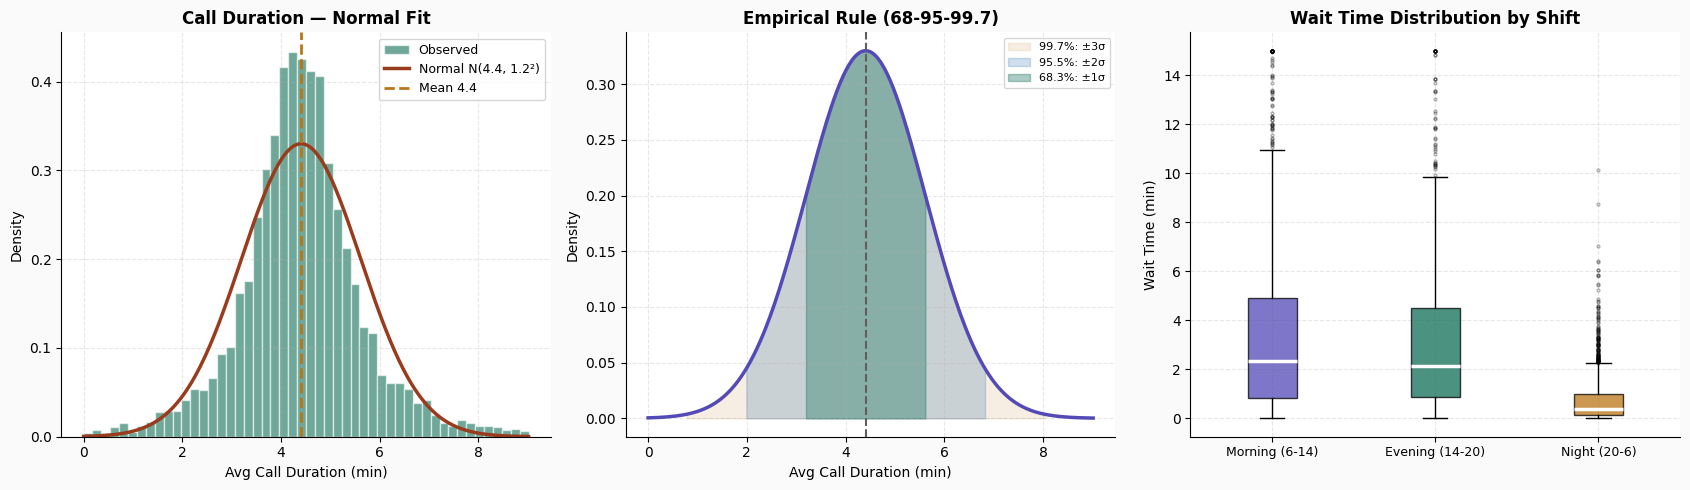

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# 1. Histogram + normal fit - Call duration எப்படி spread ஆகுது
# Histogram உருவாக்குகிறது.
# Each bar = number of calls
# Taller bar = அதிக calls
x_range = np.linspace(dur.min(), dur.max(), 300)
axes[0].hist(dur, bins=50, color=TEAL, alpha=0.6, density=True,
             edgecolor='white', label='Observed')
axes[0].plot(x_range, norm.pdf(x_range, mu_dur, std_dur),
             color=CORAL, linewidth=2.5, label=f'Normal N({mu_dur:.1f}, {std_dur:.1f}²)')
axes[0].axvline(mu_dur, color=AMBER, linewidth=2, linestyle='--', label=f'Mean {mu_dur:.1f}') # Mean = 4.4 min 👉 Average call duration: 4.4 minutes.
axes[0].set_title('Call Duration — Normal Fit', fontweight='bold')
axes[0].set_xlabel('Avg Call Duration (min)'); axes[0].set_ylabel('Density')
axes[0].legend(fontsize=9)

# 2. Empirical rule shading - Normal distribution போல இருக்கிறதா
axes[1].plot(x_range, norm.pdf(x_range, mu_dur, std_dur),
             color=PURPLE, linewidth=2.5)
shades = [(1,0.35,TEAL,'68.3%: ±1σ'),
          (2,0.20,BLUE,'95.5%: ±2σ'),
          (3,0.12,AMBER,'99.7%: ±3σ')]
for k, alpha, col, lbl in reversed(shades):
    lo = mu_dur - k*std_dur; hi = mu_dur + k*std_dur
    xf = np.linspace(lo, hi, 200)
    axes[1].fill_between(xf, norm.pdf(xf, mu_dur, std_dur),
                         alpha=alpha, color=col, label=lbl)
axes[1].axvline(mu_dur, color=DGRAY, linewidth=1.5, linestyle='--')
axes[1].set_title('Empirical Rule (68-95-99.7)', fontweight='bold')
axes[1].set_xlabel('Avg Call Duration (min)'); axes[1].set_ylabel('Density')
axes[1].legend(fontsize=8, loc='upper right')

# 📌 School Student Example
# ஒரு class imagine பண்ணுங்க:
# Most students → average marks அருகில்
# Few students மட்டும் → very low / very high marks
# அதே concept தான் bell curve.

# 3. Wait time across shifts - Different shifts-ல் wait time எப்படி இருக்கு என்பதை visual-ஆ காட்டுகிறது.
shift_data  = [df[df['shift']==s]['avg_wait_time_min'].clip(0, 15).values
               for s in ['Morning','Evening','Night']]
shift_labels = ['Morning (6-14)', 'Evening (14-20)', 'Night (20-6)']
bplot = axes[2].boxplot(shift_data, patch_artist=True,
                         medianprops=dict(color='white', linewidth=2.5),
                         flierprops=dict(marker='.', alpha=0.3, markersize=4))
for patch, col in zip(bplot['boxes'], [PURPLE, TEAL, AMBER]):
    patch.set_facecolor(col); patch.set_alpha(0.75)
axes[2].set_xticklabels(shift_labels, fontsize=9)
axes[2].set_title('Wait Time Distribution by Shift', fontweight='bold')
axes[2].set_ylabel('Wait Time (min)')

plt.tight_layout(); plt.show()

# 📌 Dots Above - Outliers.
# Very high wait times.
# Example: customer waited 12–15 mins

# 📌 Night Shift Observation, Night shift box மிகவும் small. Meaning:
# wait time குறைவு
# calls குறைவு
# faster response

# 📌 Morning & Evening , Boxes பெரியது. Meaning:
# more customers
# more variability
# longer waiting possible

# | Observation      | Meaning             |
# | ---------------- | ------------------- |
# | Morning busy     | More agents needed  |
# | Evening moderate | Medium staffing     |
# | Night low wait   | Fewer agents enough |


---
## 🎲 Step 4 — Binomial Distribution (Success/Failure Events)

> 📌 **Tamil:** "Binomial distribution = n trials-ல் எத்தனை successes நடக்கும் என்று model பண்றது. Call resolved? Yes/No — இது classic binomial problem."

### When to use Binomial?
- **Fixed number of trials** (n calls received)
- Each trial is **success or failure** (resolved or not)
- **Same probability** for each trial (p = resolution rate)
- Trials are **independent**

### Formula
```
P(X = k) = C(n,k) × p^k × (1-p)^(n-k)
```


In [ ]:
# Binomial distribution என்பது: “ஒரு fixed number of trials-ல் எத்தனை success வரும்?” என்பதை predict செய்யும் method.
# ஒவ்வொரு call-க்கும் இரண்டு outcomes மட்டும்:
# | Outcome | Meaning                     |
# | ------- | --------------------------- |
# | Success | Call resolved               |
# | Failure | Call unresolved / abandoned | 
# அதனால் இது: 👉 perfect binomial problem.


# Overall resolution probability from data
p_resolve = df['resolution_rate'].mean() #Overall average resolution rate. Example result: p = 0.84, Meaning:84% calls resolved
p_abandon = df['abandon_rate'].mean() # Customer cut/disconnected calls percentage.

# 50 calls வந்தது imagine பண்ணுங்க.
# Question: “இந்த 50 calls-ல எத்தனை resolved ஆகும்?” இதைத்தான் binomial distribution calculate பண்ணும்.
n_calls   = 50  # a busy hour with 50 calls , total tries fixed

print("── Binomial Distribution — Call Resolution ──")
print(f"  Empirical resolution rate (p): {p_resolve:.4f} = {p_resolve*100:.1f}%")
print(f"  Empirical abandon rate       : {p_abandon:.4f} = {p_abandon*100:.1f}%")
print()
print(f"  Scenario: {n_calls} calls arrive in an hour")
print()

for k in [35, 40, 42, 45, 48]: # பல situations check செய்கிறோம்: exactly 35 resolved?, exactly 40?, exactly 45?, etc.
    p_exact = binom.pmf(k, n_calls, p_resolve)  #இதுதான்: “Exactly k calls resolved ஆகும் probability”
    p_atleast = 1 - binom.cdf(k-1, n_calls, p_resolve) #“k அல்லது அதற்கு மேல் resolved ஆக chance என்ன?”
    print(f"  P(exactly {k} resolved)  = {p_exact:.4f}  |  "
          f"P(at least {k} resolved) = {p_atleast:.4f}")

expected  = n_calls * p_resolve # Expected resolved calls = total calls × resolution probability. Example: 50 calls × 0.84 = 42 calls expected to be resolved.
variance  = n_calls * p_resolve * (1 - p_resolve) # Resolved calls எவ்வளவு fluctuate(ஏற்ற இறக்கம்) ஆகும் என்பதை measure செய்கிறது.
print()

# P(exactly 35 resolved) = 0.0368
# P(at least 35 resolved) = 0.9590
# Meaning: 50 calls-ல்:
# exactly 35 resolved chance = 3.7%
# 35 அல்லது அதற்கு மேல் resolved chance = 95.9%
# 👉 35 என்பது low target. அதனால் probability மிகவும் high.
print(f"  Expected resolved calls : {expected:.1f}")
print(f"  Std Dev                 : {np.sqrt(variance):.2f}")
print(f"  ► SLA target: resolve {int(n_calls*0.85)}+ calls = "
      f"P = {(1 - binom.cdf(int(n_calls*0.85)-1, n_calls, p_resolve)):.4f}")

# E(X)=np => n = 50 calls, p = 0.793 => 50×0.793=39.65≈39.7'
# 👉 50 calls வந்தால்: average-ஆ: சுமார் 40 calls resolve ஆகும்.
# | Symbol | Meaning                |
# | ------ | ---------------------- |
# | n      | total calls            |
# | p      | resolution probability |

#  std: Var(X)=np(1-p) => 50×0.793×(1-0.793)=8.17 => Std Dev = √8.17 ≈ 2.86
# Meaning of 2.86 :👉 Resolved calls usually: 39.7 அருகில் இருக்கும். ஆனா: சுமார் ±3 calls change ஆகலாம்.

# | Situation     | Resolved Calls |
# | ------------- | -------------- |
# | Average       | 40             |
# | Slightly low  | 37             |
# | Slightly high | 42             |


── Binomial Distribution — Call Resolution ──
  Empirical resolution rate (p): 0.7930 = 79.3%
  Empirical abandon rate       : 0.0813 = 8.1%

  Scenario: 50 calls arrive in an hour

  P(exactly 35 resolved)  = 0.0368  |  P(at least 35 resolved) = 0.9590
  P(exactly 40 resolved)  = 0.1388  |  P(at least 40 resolved) = 0.5347
  P(exactly 42 resolved)  = 0.1065  |  P(at least 42 resolved) = 0.2662
  P(exactly 45 resolved)  = 0.0236  |  P(at least 45 resolved) = 0.0376
  P(exactly 48 resolved)  = 0.0008  |  P(at least 48 resolved) = 0.0009

  Expected resolved calls : 39.7
  Std Dev                 : 2.86
  ► SLA target: resolve 42+ calls = P = 0.2662


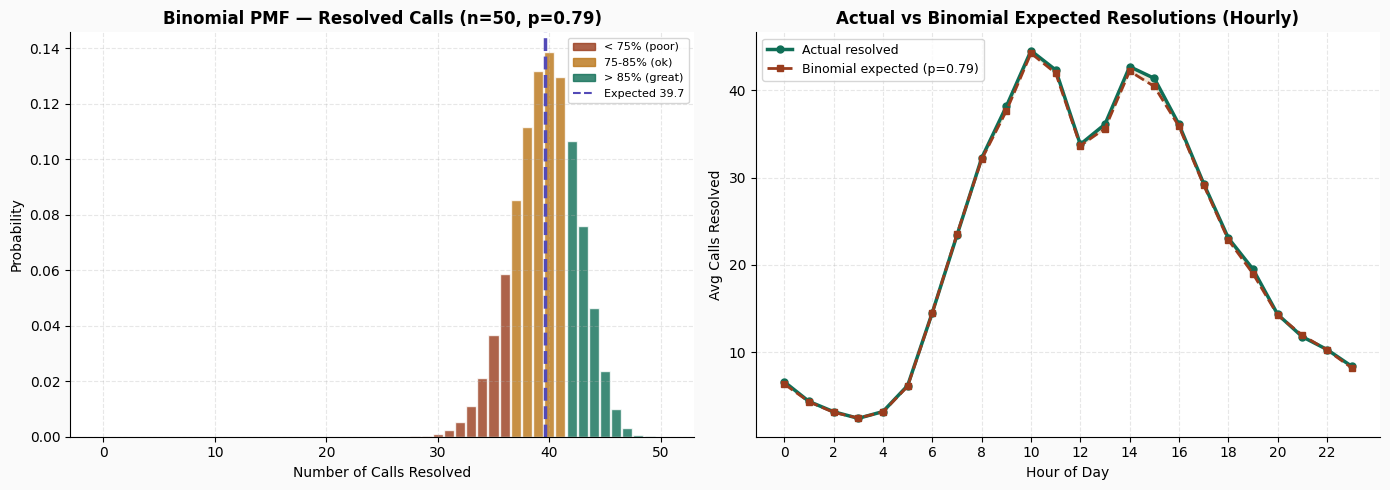

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Binomial PMF — resolution counts - 50 calls-ல் எத்தனை calls resolved ஆக வாய்ப்பு அதிகம்?
k_range = np.arange(0, n_calls + 1)
pmf_vals = binom.pmf(k_range, n_calls, p_resolve)
colors_b = [CORAL if k < int(n_calls * 0.75) else
            AMBER if k < int(n_calls * 0.85) else
            TEAL for k in k_range]
axes[0].bar(k_range, pmf_vals, color=colors_b, alpha=0.8, edgecolor='white', width=0.9)
axes[0].axvline(expected, color=PURPLE, linewidth=2.5, linestyle='--',
                label=f'Expected: {expected:.1f}')
axes[0].set_title(f'Binomial PMF — Resolved Calls (n={n_calls}, p={p_resolve:.2f})',
                  fontweight='bold')
axes[0].set_xlabel('Number of Calls Resolved')
axes[0].set_ylabel('Probability')
axes[0].legend(fontsize=9)
from matplotlib.patches import Patch
axes[0].legend(handles=[
    Patch(color=CORAL, alpha=0.8, label='< 75% (poor)'), # 50 calls-ல் 37 calls-க்கு கீழ் resolve ஆகும் probability
    Patch(color=AMBER, alpha=0.8, label='75-85% (ok)'), # 50 calls-ல் 37-42 calls resolve ஆகும் probability
    Patch(color=TEAL,  alpha=0.8, label='> 85% (great)'), # 50 calls-ல் 42 calls-க்கு மேல் resolve ஆகும் probability
    plt.Line2D([0],[0], color=PURPLE, linestyle='--', label=f'Expected {expected:.1f}')
], fontsize=8)

# 2. Actual vs Binomial expected for different hours - ஒவ்வொரு hour-ல எத்தனை calls resolve ஆகுது? அது binomial expectation-க்கு closeஆ இருக்குதா?
hourly_res = df.groupby('hour').agg(
    avg_calls=('calls_received','mean'),
    avg_resolved=('calls_resolved','mean'),
    resolution_rate=('resolution_rate','mean')
).reset_index()

expected_res = hourly_res['avg_calls'] * p_resolve

axes[1].plot(hourly_res['hour'], hourly_res['avg_resolved'], color=TEAL,
             linewidth=2.5, marker='o', markersize=5, label='Actual resolved') # உண்மையில் resolved ஆன calls.
axes[1].plot(hourly_res['hour'], expected_res, color=CORAL,
             linewidth=2, linestyle='--', marker='s', markersize=4,
             label=f'Binomial expected (p={p_resolve:.2f})') # Probability formula predict பண்ணிய expected values.
axes[1].fill_between(hourly_res['hour'],
                     hourly_res['avg_resolved'], expected_res,
                     alpha=0.15, color='#BA7517')
axes[1].set_title('Actual vs Binomial Expected Resolutions (Hourly)',
                  fontweight='bold')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Avg Calls Resolved')
axes[1].set_xticks(range(0, 24, 2))
axes[1].legend(fontsize=9)

plt.tight_layout(); plt.show()

# 📌 Morning Peak - Around: 10 AM – 4 PM , Resolved calls அதிகம். Meaning: more customer calls, more workload 
# 📌 Night Time, Night-ல்:, resolved calls குறைவு, ஏனெனில்: calls itself குறைவு.

---
## 🌟 Step 5 — Central Limit Theorem (CLT)

> 📌 **Tamil:** "CLT = statistics-இன் most important theorem. எந்த distribution-ல் இருந்தாலும், அதிலிருந்து எடுக்கும் sample means எப்போதும் Normal distribution-ஐ form பண்ணும் — sample size பெரிதாக ஆகும் போது."

### The Magic of CLT

**No matter what the original data looks like:**
- Uniform distribution
- Poisson distribution  
- Exponential distribution
- Highly skewed data

**If you take many samples and calculate their means:**
- The sample means will **always** follow a **Normal Distribution**
- Mean of sample means = **population mean**
- Std Dev of sample means = **σ / √n** (called Standard Error)

This is WHY we can do hypothesis testing on non-normal data!


In [ ]:
# 📊 CLT என்ன சொல்கிறது?
# 👉 எந்த distribution இருந்தாலும் (normal இல்லாவிட்டாலும் கூட)
# 👉 பெரிய அளவில் sample எடுத்து mean கண்டால்:
# ✔️ Sample means distribution → Normal ஆக மாறும்
# ✔️ Sample size அதிகரித்தால் spread குறையும்

# Original call data — clearly NOT normal (Poisson / skewed)
all_calls = df['calls_received'].values

print("── Central Limit Theorem Demonstration ──")
print(f"  Population mean (μ)    : {all_calls.mean():.4f}")
print(f"  Population std dev (σ) : {all_calls.std():.4f}")
print()

# நீங்கள் 4 sample sizes எடுத்திருக்கிறீர்கள்: நோக்கம்: sample size அதிகரிக்கும்போது என்ன change ஆகுது என்பதை காட்டுவது.
#n = 5 → small sample
# n = 15 → medium
# n = 30 → CLT threshold (important)
# n = 100 → large sample
# ஒவ்வொன்றுக்கும்:
# 👉 2000 samples எடுத்து mean கணக்கிடுகிறீர்கள்
# 👉 அந்த means-ன் spread (standard error) பார்க்கிறீர்கள்
results = {}
for n in [5, 15, 30, 100]:
    sample_means = [np.random.choice(all_calls, size=n, replace=False).mean()
                    for _ in range(2000)]
    results[n] = sample_means
    se_theory = all_calls.std() / np.sqrt(n)
    print(f"  n = {n:>3}  |  Sample mean: {np.mean(sample_means):.3f}  "
          f"|  SE observed: {np.std(sample_means):.3f}  "
          f"|  SE theory (σ/√n): {se_theory:.3f}  "
          f"|  Match: {'✅' if abs(np.std(sample_means)-se_theory) < 0.1 else '⚠️'}")

print()
print("  ► KEY INSIGHT:")
print("    As n increases, the sample means converge to Normal distribution")
print("    AND the spread (Standard Error) decreases — more precision!")

#  🔑 முக்கிய கருத்து (KEY INSIGHT): 👉 sample size (n) அதிகரிக்கும்போது:
# ✔️ sample means distribution : 👉 Normal distribution (Bell curve) போல மாறுகிறது
# ✔️ Standard Error (SE) :👉 குறைய ஆரம்பிக்கிறது, 👉 அதனால் prediction மேலும் துல்லியமாக (more precise) ஆகிறது

── Central Limit Theorem Demonstration ──
  Population mean (μ)    : 27.4688
  Population std dev (σ) : 20.4955

  n =   5  |  Sample mean: 27.462  |  SE observed: 9.237  |  SE theory (σ/√n): 9.166  |  Match: ✅
  n =  15  |  Sample mean: 27.674  |  SE observed: 5.415  |  SE theory (σ/√n): 5.292  |  Match: ⚠️
  n =  30  |  Sample mean: 27.414  |  SE observed: 3.616  |  SE theory (σ/√n): 3.742  |  Match: ⚠️
  n = 100  |  Sample mean: 27.397  |  SE observed: 2.037  |  SE theory (σ/√n): 2.050  |  Match: ✅

  ► KEY INSIGHT:
    As n increases, the sample means converge to Normal distribution
    AND the spread (Standard Error) decreases — more precision!



📌 2. Sample Mean எப்படி வருகிறது?
np.random.choice(all_calls, size=n, replace=False).mean()
இதன் meaning:

👉 population data = all_calls

Step-by-step:
✔️ Step 1: Random sample எடுக்கிறோம்

Example (n = 5):

[20, 35, 10, 40, 30]
✔️ Step 2: Mean எடுக்கிறோம்

👉 இந்த 5 values average = sample mean

✔️ Step 3:

இதையே 2000 times repeat செய்கிறீர்கள்

👉 அதனால் 2000 sample means கிடைக்கும்

📌 3. SE observed எப்படி வந்தது?
np.std(sample_means)

👉 இதுதான் SE observed

Meaning:

👉 sample means எல்லாம் எவ்வளவு spread ஆக இருக்கிறது?

Example:

n = 5 க்கு 2000 sample means:

[25, 40, 10, 30, 35, ...]

👉 இவை எல்லாம் ஒரு distribution

👉 இதன் standard deviation = SE observed

Simple meaning:

👉 “Sample mean எவ்வளவு fluctuate ஆகுது?”

📌 4. SE theory எப்படி வந்தது?
se_theory = all_calls.std() / np.sqrt(n)
Formula:

இதில்:
σ = population standard deviation (20.49)
n = sample size

👉 இது theoretical expectation

📌 5. “Match” என்ன அர்த்தம்?
abs(np.std(sample_means) - se_theory) < 0.1
Meaning:

👉 observed SE மற்றும் theory SE close இருக்கிறதா?

Example:
n = 5:
observed = 9.237
theory = 9.166
👉 difference = 0.071 → small
👉 ✔️ Match ✅
n = 30:
observed = 3.616
theory = 3.742
👉 difference = 0.126
👉 ❌ slightly off → ⚠️ warning
So:
Symbol	Meaning
✅	theory ≈ real simulation
⚠️	small difference (random sampling error)
🎯 Overall Concept (Simple Tamil)

👉 நீங்கள் என்ன செய்கிறீர்கள்:

1. Population data எடுத்துக்கொள்கிறீர்கள்
2. Random sample எடுக்கிறீர்கள்
3. அந்த sample mean கணக்கிடுகிறீர்கள்
4. அதை 2000 times repeat செய்கிறீர்கள்
5. அந்த means-ன் spread பார்க்கிறீர்கள் (SE observed)
6. formula மூலம் expected spread கணக்கிடுகிறீர்கள் (SE theory)
7. இரண்டும் compare செய்கிறீர்கள் (Match)

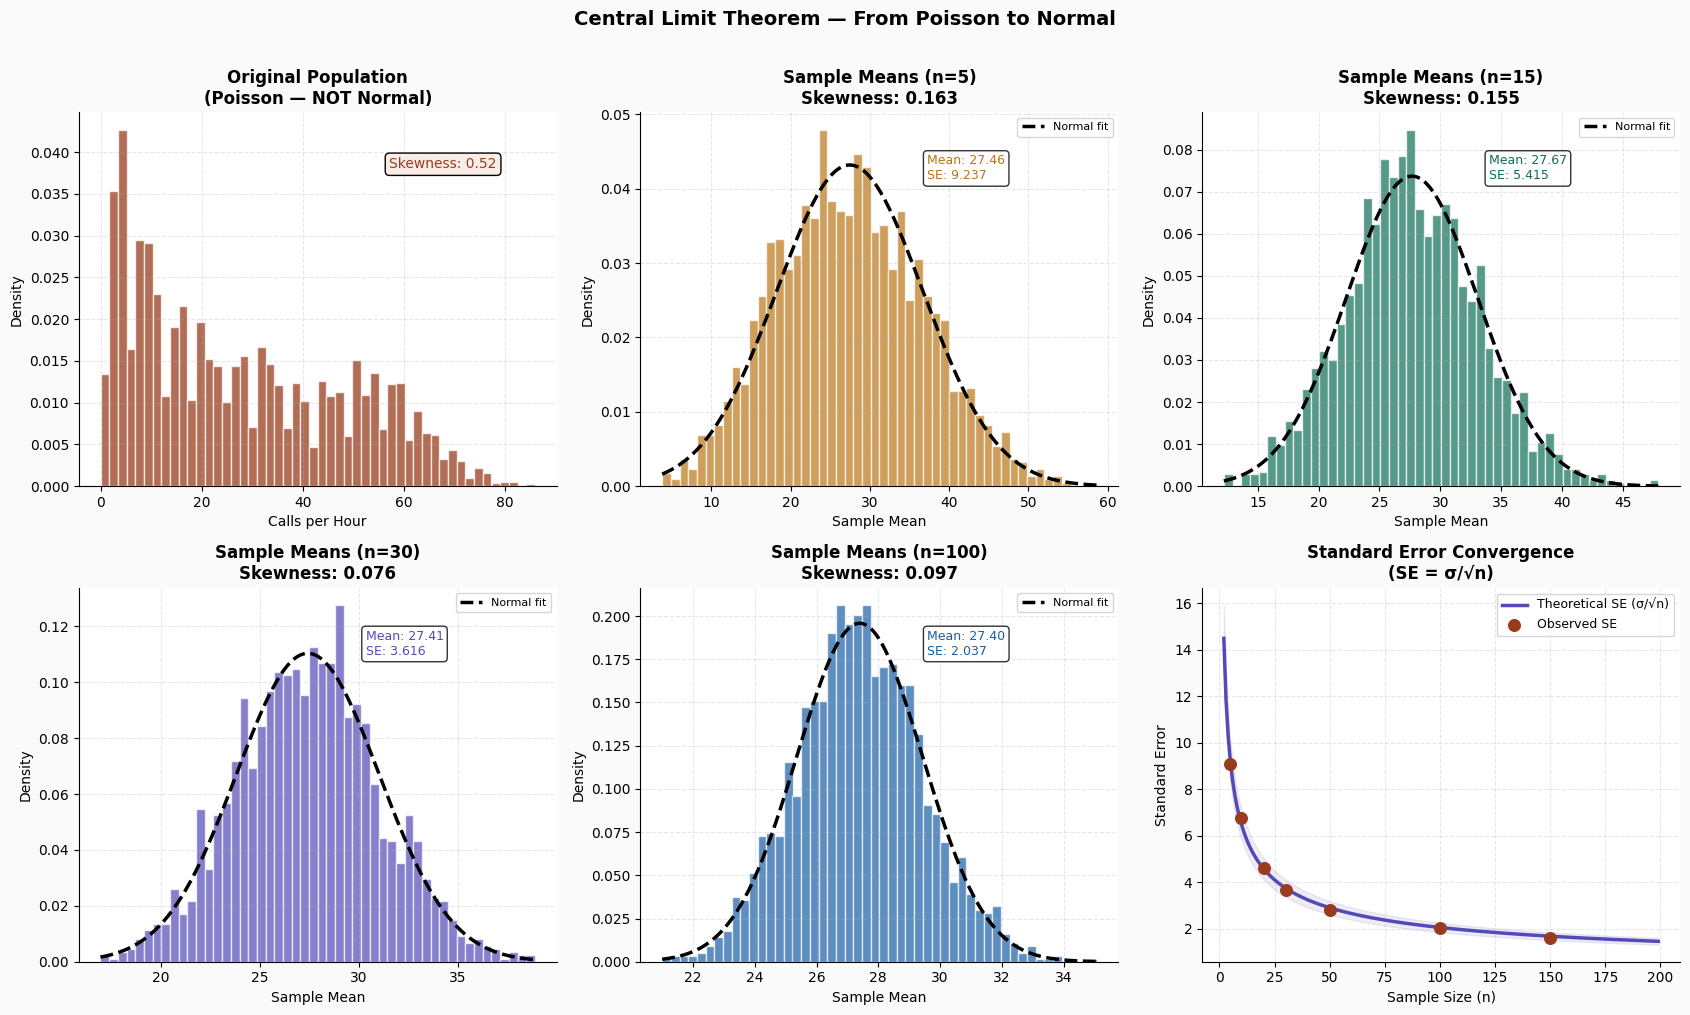

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle('Central Limit Theorem — From Poisson to Normal',
             fontsize=14, fontweight='bold', y=1.01)

# Top-left: Original population distribution
axes[0,0].hist(all_calls, bins=50, color=CORAL, alpha=0.75,
               density=True, edgecolor='white')
axes[0,0].set_title('Original Population\n(Poisson — NOT Normal)', fontweight='bold')
axes[0,0].set_xlabel('Calls per Hour'); axes[0,0].set_ylabel('Density')
axes[0,0].text(0.65, 0.85, f'Skewness: {pd.Series(all_calls).skew():.2f}',
               transform=axes[0,0].transAxes, color=CORAL, fontsize=10,
               bbox=dict(boxstyle='round', facecolor='#FAECE7'))

# CLT for n = 5, 15, 30, 100
plot_configs = [(5,AMBER,axes[0,1]),(15,TEAL,axes[0,2]),
                (30,PURPLE,axes[1,0]),(100,BLUE,axes[1,1])]
for n, col, ax in plot_configs:
    sm = results[n]
    ax.hist(sm, bins=50, color=col, alpha=0.70, density=True, edgecolor='white')
    mu_s = np.mean(sm); std_s = np.std(sm)
    x_fit = np.linspace(min(sm), max(sm), 200)
    ax.plot(x_fit, norm.pdf(x_fit, mu_s, std_s),
            color='black', linewidth=2.5, linestyle='--', label='Normal fit')
    skew_sm = pd.Series(sm).skew()
    ax.set_title(f'Sample Means (n={n})\nSkewness: {skew_sm:.3f}', fontweight='bold')
    ax.set_xlabel('Sample Mean'); ax.set_ylabel('Density')
    ax.legend(fontsize=8)
    ax.text(0.60, 0.82,
            f'Mean: {mu_s:.2f}\nSE: {std_s:.3f}',
            transform=ax.transAxes, fontsize=9, color=col,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Bottom-right: SE convergence - n அதிகரிக்கும்போது: SE curve கீழே இறங்குகிறது, error குறைகிறது
ns   = np.arange(2, 200)
se_t = all_calls.std() / np.sqrt(ns)
axes[1,2].plot(ns, se_t, color=PURPLE, linewidth=2.5, label='Theoretical SE (σ/√n)')
observed_ses = [np.std([np.random.choice(all_calls,n,replace=False).mean()
                        for _ in range(500)]) for n in [5,10,20,30,50,100,150]]
axes[1,2].scatter([5,10,20,30,50,100,150], observed_ses,
                  color=CORAL, s=70, zorder=5, label='Observed SE')
axes[1,2].set_title('Standard Error Convergence\n(SE = σ/√n)', fontweight='bold')
axes[1,2].set_xlabel('Sample Size (n)'); axes[1,2].set_ylabel('Standard Error')
axes[1,2].legend(fontsize=9)
axes[1,2].fill_between(ns, se_t*0.9, se_t*1.1, alpha=0.1, color=PURPLE)

plt.tight_layout(); plt.show()

# 5th chart:  large sample → almost perfect normal distribution + high accuracy”

# 🟠 1. Original data:
# 👉 skewed / Poisson (normal இல்லை)

# 🟡 2. Small sample (n=5):
# 👉 noisy, unstable

# 🟢 3. Medium sample (n=15–30):
# 👉 normal shape உருவாக ஆரம்பிக்கிறது

# 🔵 4. Large sample (n=100):
# 👉 perfect bell curve

# 📉 5. SE graph:
# 👉 sample size அதிகரிக்கும்போது error குறைகிறது



---
## 📏 Step 6 — Z-Scores (Standardization)

> 📌 **Tamil:** "Z-score = ஒரு value, mean-இலிருந்து எத்தனை standard deviations தூரத்தில் இருக்கிறது என்று சொல்கிறது. Outlier detection-க்கும், different scales compare பண்ண-வும் use பண்றோம்."

👉 ஒரு value mean-இலிருந்து எவ்வளவு distance (σ units) தூரத்தில் இருக்கிறது என்பதை காட்டும் measure.

### Formula
```
Z = (X - μ) / σ
```

### Interpretation
| Z-score | Meaning |
|---------|---------|
| `0` | Exactly at the mean |
| `+2` | 2 std devs above mean — unusually high |
| `-2` | 2 std devs below mean — unusually low |
| `|Z| > 3` | Extreme outlier (0.3% chance in normal distribution) |

### Business Use: Anomaly Detection
Identify hours with abnormally high call volumes → auto-alert the manager!


In [ ]:
# 👉 “ஒரு value normal-ஆ இருக்கிறதா இல்லையா என்பதை கண்டுபிடிக்க உதவும் score”

# Compute Z-scores for hourly call volumes 
mu_calls  = df['calls_received'].mean()
std_calls = df['calls_received'].std()

df['z_score_calls'] = (df['calls_received'] - mu_calls) / std_calls # Z-score formula: (X - μ) / σ

print("── Z-Score Analysis — Call Volume Anomalies ──")
print(f"  Population Mean (μ) : {mu_calls:.2f}")
print(f"  Population Std (σ)  : {std_calls:.2f}")
print()
print(f"  Normal range (|Z| ≤ 2): {mu_calls-2*std_calls:.1f} — {mu_calls+2*std_calls:.1f} calls") # μ ± 2σ - 👉 range = -13.5 to 68.5 calls
print(f"  Alert range  (|Z| ≥ 2): outside this range")
print(f"  Critical     (|Z| ≥ 3): {mu_calls-3*std_calls:.1f} — {mu_calls+3*std_calls:.1f} calls") # μ ± 3σ - 👉 very rare events
print()

# Anomalous hours - தாறுமாறான hour
anomalies = df[df['z_score_calls'].abs() > 2].sort_values('z_score_calls', ascending=False)
print(f"  Anomalous hours (|Z|>2)  : {len(anomalies)} / {len(df)} "
      f"= {len(anomalies)/len(df)*100:.1f}%  (theory: 5%)") # Total data = 4320 hours 👉  அதில் 102 hours “anomaly” (unusual calls)
print(f"  Critical hours  (|Z|>3)  : {(df['z_score_calls'].abs() > 3).sum()}") # 0 critical events 👉 dataset-ல் extreme spikes இல்லை
print()
print("  Top 5 highest-volume anomalies:")
top5 = anomalies.head(5)[['date','hour','day_of_week','calls_received','z_score_calls']]
print(top5.to_string(index=False))

# 📌 Meaning:
# 👉 10 AM Tuesday
# 👉 normal-ஐ விட 2.85σ அதிகம்
# 👉 very high traffic
# 📌 4. Overall Pattern (Important Insight) 🔥 What we observe:
# ✔️ Most anomalies: 👉 10 AM around
# ✔️ Other spikes: 👉 14–15 PM

── Z-Score Analysis — Call Volume Anomalies ──
  Population Mean (μ) : 27.47
  Population Std (σ)  : 20.50

  Normal range (|Z| ≤ 2): -13.5 — 68.5 calls
  Alert range  (|Z| ≥ 2): outside this range
  Critical     (|Z| ≥ 3): -34.0 — 89.0 calls

  Anomalous hours (|Z|>2)  : 102 / 4320 = 2.4%  (theory: 5%)
  Critical hours  (|Z|>3)  : 0

  Top 5 highest-volume anomalies:
      date  hour day_of_week  calls_received  z_score_calls
2024-03-19    10         Tue              86       2.855483
2024-06-03    10         Mon              85       2.806698
2024-05-07    10         Tue              82       2.660341
2024-06-28    15         Fri              82       2.660341
2024-04-22    14         Mon              81       2.611555


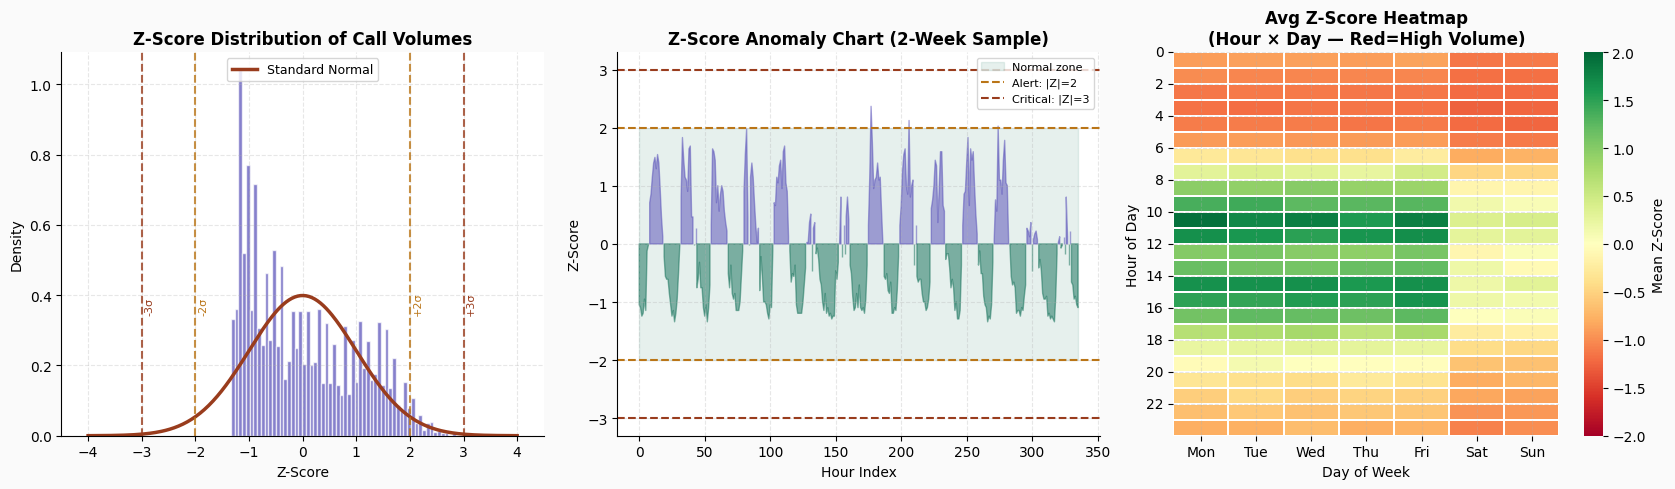

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# 1. Z-score distribution - எல்லா calls-க்கும் calculate பண்ணப்பட்ட Z-scores distribution
# 📏 vertical lines:
# -2σ (warning start)
# +2σ (alert start)
# -3σ (critical low)
# +3σ (critical high)
z_scores = df['z_score_calls']
axes[0].hist(z_scores, bins=60, color=PURPLE, alpha=0.7,
             density=True, edgecolor='white')
x_z = np.linspace(-4, 4, 300)
axes[0].plot(x_z, norm.pdf(x_z), color=CORAL, linewidth=2.5,
             label='Standard Normal')
for z_thr, col, lbl in [(-2,AMBER,'-2σ'),(2,AMBER,'+2σ'),(-3,CORAL,'-3σ'),(3,CORAL,'+3σ')]:
    axes[0].axvline(z_thr, color=col, linestyle='--', linewidth=1.5, alpha=0.8)
    axes[0].text(z_thr+0.05, 0.35, lbl, color=col, fontsize=8, rotation=90)
axes[0].set_title('Z-Score Distribution of Call Volumes', fontweight='bold')
axes[0].set_xlabel('Z-Score'); axes[0].set_ylabel('Density')
axes[0].legend(fontsize=9)
axes[0].set_xlim(-4.5, 4.5)
# data normal distribution போல இருக்கிறதா என்பதை check பண்ணுகிறது”
# ✔️ most values -2 to +2 உள்ளே இருக்கும்
# ✔️ outside values → anomaly

# 2. Z-scores over time (anomaly chart) - 👉 first 2 weeks call pattern-ல் Z-score variation

# 🟢 Green zone (-2 to +2)
# 👉 normal range
# 👉 expected behavior

# 🟣 Purple spikes
# 👉 high call volume (positive anomalies)

# 🔵 Teal areas
# 👉 low activity (negative deviations)

sample_week = df[df['date'] <= df['date'].min() + pd.Timedelta(days=13)]
axes[1].fill_between(range(len(sample_week)), -2, 2, alpha=0.1, color=TEAL, label='Normal zone')
axes[1].fill_between(range(len(sample_week)),
                     sample_week['z_score_calls'].values, 0,
                     where=sample_week['z_score_calls'].values > 0,
                     color=PURPLE, alpha=0.5)
axes[1].fill_between(range(len(sample_week)),
                     sample_week['z_score_calls'].values, 0,
                     where=sample_week['z_score_calls'].values < 0,
                     color=TEAL, alpha=0.5)
axes[1].axhline(2,  color=AMBER, linestyle='--', linewidth=1.5, label='Alert: |Z|=2')
axes[1].axhline(-2, color=AMBER, linestyle='--', linewidth=1.5)
axes[1].axhline(3,  color=CORAL, linestyle='--', linewidth=1.5, label='Critical: |Z|=3')
axes[1].axhline(-3, color=CORAL, linestyle='--', linewidth=1.5)
axes[1].set_title('Z-Score Anomaly Chart (2-Week Sample)', fontweight='bold')
axes[1].set_xlabel('Hour Index'); axes[1].set_ylabel('Z-Score')
axes[1].legend(fontsize=8)

# 3. Z-score heatmap by hour × day - average Z-score for each: Hour (0–23), Day (Mon–Sun)
# 🔴 Red = Low call activity
# 👉 Z-score negative
# 👉 Calls are below average

# 🟢 Green = High call activity
# 👉 Z-score positive
# 👉 Calls are above average

# 🟡 Yellow = Normal baseline
# 👉 Z ≈ 0
# 👉 Close to mean

# -2 → strongest red (low anomaly)
# 0 → yellow (normal)
# +2 → strongest green (high activity)

pivot_z = df.groupby(['hour','day_of_week'])['z_score_calls'].mean().unstack()
day_order = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
pivot_z = pivot_z.reindex(columns=[d for d in day_order if d in pivot_z.columns])
sns.heatmap(pivot_z, ax=axes[2], cmap='RdYlGn',
            center=0, vmin=-2, vmax=2,
            linewidths=0.3, linecolor='white',
            cbar_kws={'label':'Mean Z-Score'})
axes[2].set_title('Avg Z-Score Heatmap\n(Hour × Day — Red=High Volume)', fontweight='bold')
axes[2].set_xlabel('Day of Week'); axes[2].set_ylabel('Hour of Day')
axes[2].set_yticks(range(0,24,2)); axes[2].set_yticklabels(range(0,24,2))

plt.tight_layout(); plt.show()

---
## 🎯 Step 7 — Sampling Methods

> 📌 **Tamil:** "Sampling = whole population-ஐ study பண்ண முடியாத போது, ஒரு representative subset எடுக்கிறோம். Survey, quality check, A/B test எல்லாவற்றிலும் use பண்றோம்."

| Method | How | When to use |
|--------|-----|------------|
| **Simple Random** | Every record equal chance | Quick estimates |
| **Stratified** | Sample proportionally from each group | Groups of different sizes |
| **Systematic** | Every k-th record | Large ordered datasets |
| **Cluster** | Random clusters → sample all inside | Geographic/time data |

> 📌 Sampling என்றால் என்ன?     
> 👉 முழு dataset (population)-ஐ analyze பண்ணாமல்        
> 👉 அதிலிருந்து ஒரு சிறிய representative data எடுத்துக் கொள்வது       

> 📌 1. SIMPLE RANDOM SAMPLING      
> 👉 எல்லா rows-க்கும் equal chance      
> 👉 random-ஆ 500 rows pick ஆகும்     
> ✔️ Pros: unbiased,easy        
> ❌ Cons:groups imbalance ஆகலாம்     

> 2. STRATIFIED(அடுக்கடுக்காக) SAMPLING (MOST IMPORTANT)     
> 👉 data-வை groups (strata) ஆ பிரிக்கிறோம்
Shift:- Morning,- Afternoon,- Night     
> 👉 ஒவ்வொரு group-லிருந்தும் proportional sample எடுக்கிறோம்
Morning = 50%, Afternoon = 30%, Night = 20%     
> 👉 sample 500 என்றால்:
Morning → 250, Afternoon → 150, Night → 100     

📌 3. SYSTEMATIC SAMPLING
👉 fixed interval-ல் sample எடுப்பது
k = 10 : 👉 ஒவ்வொரு 10th row எடுத்துக் கொள்கிறோம்
✔️ Pros: fast, simple
❌ Risk: pattern bias வரலாம்

4. CLUSTER SAMPLING (theory mention):
👉 groups (clusters) random-ஆ select
👉 அந்த group முழுவதும் take
Example: Chennai calls ,Delhi calls ,Mumbai calls
👉 one city pick → all data use

🔑 “Stratified is best”
காரணம்:
👉 shift (Morning/Afternoon/Night) structure preserve ஆகிறது
👉 data imbalance வராது
👉 real population pattern 그대로 இருக்கும்

In [ ]:
N = len(df)  # population size
n = 500      # desired sample size

np.random.seed(42)

# 1. Simple Random Sampling
simple_random = df.sample(n=n, replace=False, random_state=42)

# 2. Stratified Sampling (proportional by shift)
shift_props = df['shift'].value_counts(normalize=True)
stratified_frames = []
for shift, prop in shift_props.items():
    stratum = df[df['shift'] == shift]
    k = int(n * prop)
    stratified_frames.append(stratum.sample(n=k, random_state=42))
stratified = pd.concat(stratified_frames)

# 3. Systematic Sampling (every k-th row)
k = N // n
systematic = df.iloc[::k].head(n)

print("── Sampling Methods Comparison ──")
print(f"  Population size: {N:,}")
print(f"  Target sample size: {n}")
print()

# Method        Mean Calls   Std Dev
# -----------------------------------
# Simple Random     ~27.x       varied
# Stratified        ~27.x       closest to population
# Systematic        slightly biased possible
# Population         true value
# 👉 “எந்த sampling method population data-க்கு எவ்வளவு close-ஆ இருக்கிறது என்பதை compare பண்ணும் table”

print(f"  {'Method':<25} {'n':>6} {'Mean Calls':>12} {'Std Dev':>10}")
print("  " + "─" * 57)
for name, sample in [("Simple Random", simple_random), 
                      ("Stratified", stratified),
                      ("Systematic", systematic),
                      ("Population", df)]:
    mu  = sample['calls_received'].mean()
    std = sample['calls_received'].std()
    print(f"  {name:<25} {len(sample):>6,} {mu:>12.3f} {std:>10.3f}")

print()
print("  ► KEY: Stratified gives MOST representative sample")
print("    because it preserves the shift distribution!")
# 👉 “Call center data-ல random எடுப்பதை விட, shift-wise balanced sample எடுத்தால் தான் உண்மையான business reality-க்கு closest result கிடைக்கும் — அதுதான் Stratified sampling.”

── Sampling Methods Comparison ──
  Population size: 4,320
  Target sample size: 500

  Method                         n   Mean Calls    Std Dev
  ─────────────────────────────────────────────────────────
  Simple Random                500       27.004     20.931
  Stratified                   499       27.503     20.460
  Systematic                   500       31.010     19.325
  Population                 4,320       27.469     20.498

  ► KEY: Stratified gives MOST representative sample
    because it preserves the shift distribution!


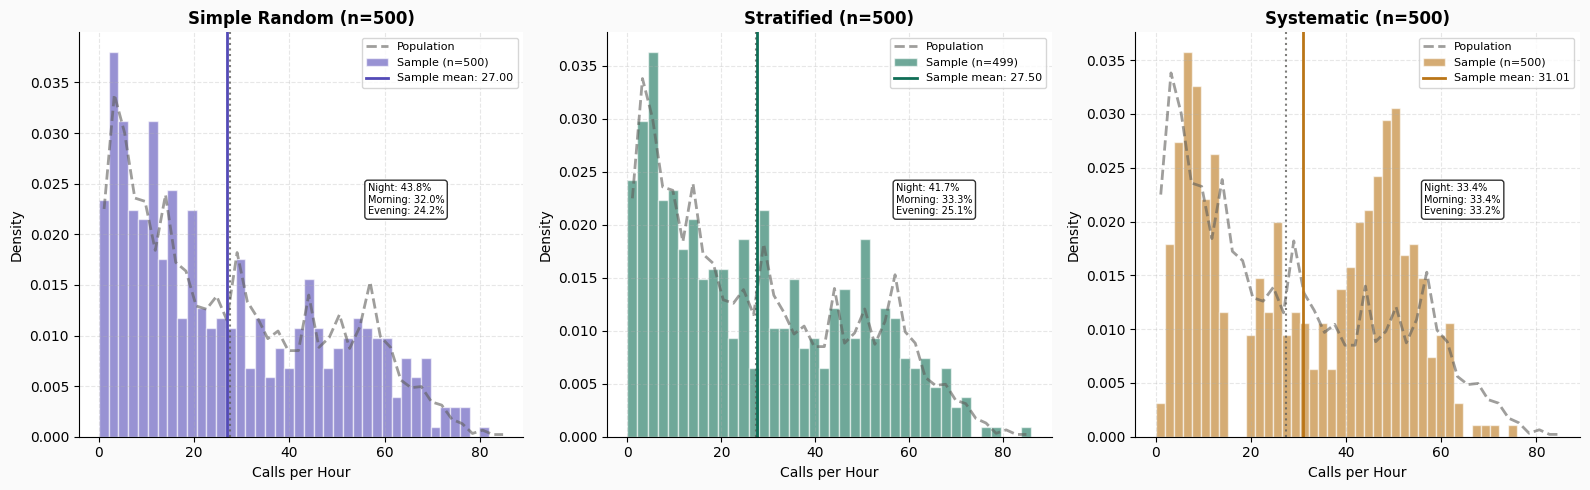

In [ ]:
# ஒரு sample “best” என்பதை decide பண்ண: 👉 mean மட்டும் பார்க்கக்கூடாது
# நாம் பார்க்க வேண்டியது:
# Mean close-ஆ?
# Std deviation close-ஆ?
# Distribution shape match ஆகுதா?
# Group proportions preserve ஆகுதா?
# Stability / consistency இருக்கா?

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

samples = [('Simple Random (n=500)', simple_random, PURPLE),
           ('Stratified (n=500)',    stratified,     TEAL),
           ('Systematic (n=500)',    systematic,     AMBER)]

for ax, (name, samp, col) in zip(axes, samples):
    pop_hist, bins = np.histogram(df['calls_received'], bins=40, density=True)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    ax.plot(bin_centers, pop_hist, color=DGRAY, linewidth=2,
            alpha=0.6, label='Population', linestyle='--')
    ax.hist(samp['calls_received'], bins=40, color=col, alpha=0.6,
            density=True, edgecolor='white', label=f'Sample (n={len(samp)})')
    ax.axvline(df['calls_received'].mean(),  color=DGRAY, linewidth=1.5,
               linestyle=':', alpha=0.8)
    ax.axvline(samp['calls_received'].mean(), color=col, linewidth=2,
               linestyle='-', label=f'Sample mean: {samp["calls_received"].mean():.2f}')
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Calls per Hour'); ax.set_ylabel('Density')
    ax.legend(fontsize=8)
    # Add shift distribution check
    shift_check = samp['shift'].value_counts(normalize=True)
    txt = "\n".join([f"{s}: {p:.1%}" for s,p in shift_check.items()])
    ax.text(0.65, 0.55, txt, transform=ax.transAxes, fontsize=7,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout(); plt.show()

# 1. chart : 
# Night: 43.8%,
# Morning: 32.0%,
# Evening: 24.2%
# 👉 Night shifts அதிகம் capture ஆயிடுச்சு. அதனால் slight imbalance.
# 2. chart :
# Night: 41.7%
# Morning: 33.3%
# Evening: 25.1%
# 👉 perfectly balanced proportions
# 3. chart :
# Night: 33.4%
# Morning: 33.4%
# Evening: 33.2%
# 👉 shifts balanced போல தெரிகிறது
# BUT…👉 call volume pattern biased ஆகிவிட்டது.

---
## 🧮 Step 8 — Practical Probability Calculations for Staffing

> 📌 **Tamil:** "இப்போ எல்லா distributions-ஐயும் learn பண்ணோம். இப்போ business questions-க்கு real probability calculations பண்ணுவோம்."

📖 🎯 Story — “Call Center Staffing Dashboard”

ஒரு பெரிய customer support call center இருக்கு.

Manager பெயர் Anita.

அவளுக்கு ஒரு பெரிய problem:

“எந்த shift-க்கு எத்தனை agents வைக்கணும்?”

குறைவாக வைத்தால்:

customers wait பண்ணுவாங்க 😡

அதிகமாக வைத்தால்:

company unnecessary salary செலவு 💸

அதனால் Anita statistics use பண்ணி smart staffing plan உருவாக்குறாள்.

In [ ]:
print("=" * 65)
print("  STAFFING PROBABILITY DASHBOARD")
print("=" * 65)

# By shift - ஒரு நாளை 3 business shifts-ஆ பிரிக்கிறோம்:
for shift_name, hour_range in [('Morning (6-14)', range(6,14)),
                                ('Evening (14-20)', range(14,20)),
                                ('Night (20-24 & 0-6)', list(range(20,24))+list(range(0,6)))]:
    subset = df[df['hour'].isin(hour_range) & ~df['is_weekend']] # Weekday-ல மட்டும் consider பண்ணுகிறோம், weekend-ல pattern வேறாக இருக்கலாம்
    lam_shift = subset['calls_received'].mean() # Poisson distribution-ல்: λ=average calls per hour  - “இந்த shift-ல் average-ஆ ஒரு மணி நேரத்திற்கு எத்தனை calls வருகிறது?”
    p50 = poisson.ppf(0.50, lam_shift) # “இந்த shift-ல் 50% நேரத்தில் எத்தனை calls வரலாம்?” (median)
    p90 = poisson.ppf(0.90, lam_shift) # “இந்த shift-ல் 90% நேரத்தில் எத்தனை calls வரலாம்?” (90th percentile)
    p99 = poisson.ppf(0.99, lam_shift) # “இந்த shift-ல் 99% நேரத்தில் எத்தனை calls வரலாம்?” (99th percentile)
    p_over50 = 1 - poisson.cdf(50, lam_shift) # 👉 “ஒரு மணி நேரத்தில் 50 calls-ஐ தாண்டும் chance எவ்வளவு?”
    print(f"\n  {shift_name}")
    print(f"    λ (avg calls/hour)     : {lam_shift:.1f}")
    print(f"    Median capacity needed  : {int(p50)} calls  → {int(np.ceil(p50/8))} agents")
    print(f"    90% SLA capacity        : {int(p90)} calls  → {int(np.ceil(p90/8))} agents")
    print(f"    99% SLA capacity        : {int(p99)} calls  → {int(np.ceil(p99/8))} agents")
    print(f"    P(calls > 50)           : {p_over50:.4f} = {p_over50*100:.2f}%")
# P(calls > 50) = 32.19% - Morning shift-ல்: 50 calls-ஐ தாண்டும் chance 32% மூன்றில் ஒரு நேரம் overload வர வாய்ப்பு இருக்கு.”
# P(calls > 50) = Evening overload risk lower than morning.
#  P(calls > 50) = 👉 Night overload almost impossible.
print("\n" + "=" * 65)
print("  RECOMMENDED STAFFING SCHEDULE (agents, assuming 8 calls/agent/hr)") # ஒவ்வொரு hour-க்கும் average calls calculate செய்கிறோம். எத்தனை agents தேவை என்று plan பண்ணுகிறாள்
print("=" * 65)
schedule = df[~df['is_weekend']].groupby('hour')['calls_received'].mean()
for hour, avg_calls in schedule.items():
    agents_90 = int(np.ceil(poisson.ppf(0.90, avg_calls) / 8)) # 👉 90% safety level maintain செய்ய எத்தனை agents தேவை?
    agents_99 = int(np.ceil(poisson.ppf(0.99, avg_calls) / 8))
    bar = '█' * agents_90
    print(f"  {hour:02d}:00  |  {bar:<20}  90%:{agents_90:>2} agents  99%:{agents_99:>2} agents  λ={avg_calls:.1f}")

# 🌃 00:00 — Midnight
# ██   → 2 agents
# λ = 9.4
# இரவு 12 மணி. பெரும்பாலான customers தூங்குறாங்க 😴 calls குறைவு
# Average: λ=9.4 👉 1 hour-க்கு around 9 calls.
# 👥 Staffing 👉 90% situations handle செய்ய: 2 agents போதும்
# 👉 Worst case: 3 agents safe


  STAFFING PROBABILITY DASHBOARD

  Morning (6-14)
    λ (avg calls/hour)     : 47.4
    Median capacity needed  : 47 calls  → 6 agents
    90% SLA capacity        : 56 calls  → 7 agents
    99% SLA capacity        : 64 calls  → 8 agents
    P(calls > 50)           : 0.3219 = 32.19%

  Evening (14-20)
    λ (avg calls/hour)     : 45.7
    Median capacity needed  : 46 calls  → 6 agents
    90% SLA capacity        : 54 calls  → 7 agents
    99% SLA capacity        : 62 calls  → 8 agents
    P(calls > 50)           : 0.2352 = 23.52%

  Night (20-24 & 0-6)
    λ (avg calls/hour)     : 10.1
    Median capacity needed  : 10 calls  → 2 agents
    90% SLA capacity        : 14 calls  → 2 agents
    99% SLA capacity        : 18 calls  → 3 agents
    P(calls > 50)           : 0.0000 = 0.00%

  RECOMMENDED STAFFING SCHEDULE (agents, assuming 8 calls/agent/hr)
  00:00  |  ██                    90%: 2 agents  99%: 3 agents  λ=9.4
  01:00  |  ██                    90%: 2 agents  99%: 2 agents  λ=6.3


---
## 🖥️ Step 9 — Complete Business Dashboard

All probability distributions + staffing insights in one view.


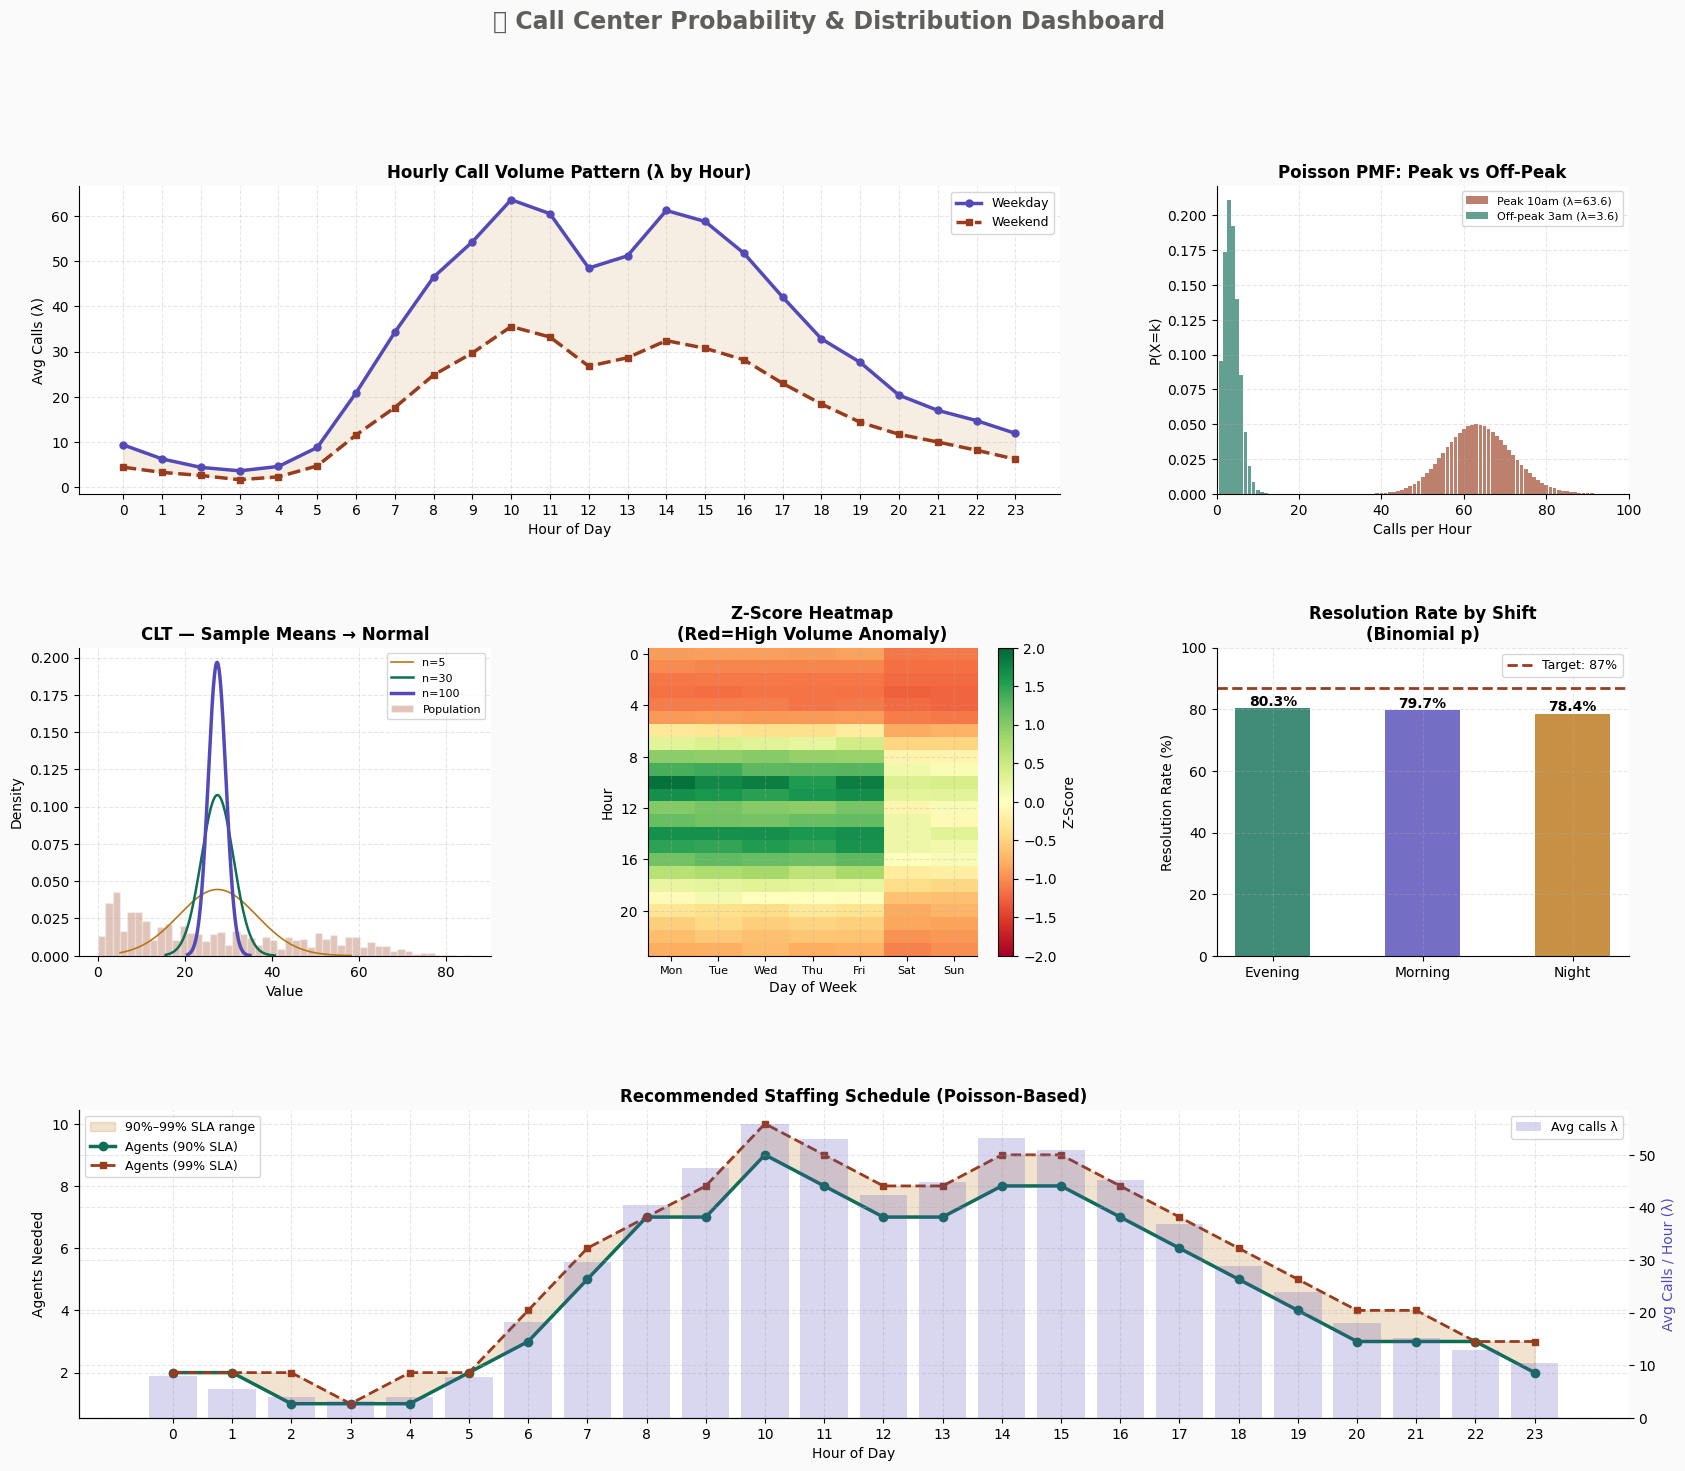


✅ Dashboard saved as 'stage2_probability_dashboard.png'


In [27]:
fig = plt.figure(figsize=(20, 16))
fig.suptitle('📞 Call Center Probability & Distribution Dashboard',
             fontsize=17, fontweight='bold', color=DGRAY, y=0.99)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.50, wspace=0.38)

# P1: Hourly pattern
ax1 = fig.add_subplot(gs[0, :2])
hourly_avg_wd = df[~df['is_weekend']].groupby('hour')['calls_received'].mean()
hourly_avg_we = df[df['is_weekend']].groupby('hour')['calls_received'].mean()
ax1.plot(hourly_avg_wd.index, hourly_avg_wd.values, color=PURPLE, linewidth=2.5,
         marker='o', markersize=5, label='Weekday')
ax1.plot(hourly_avg_we.index, hourly_avg_we.values, color=CORAL, linewidth=2.5,
         linestyle='--', marker='s', markersize=5, label='Weekend')
ax1.fill_between(hourly_avg_wd.index, hourly_avg_wd.values, hourly_avg_we.values,
                 alpha=0.12, color=AMBER)
ax1.set_title('Hourly Call Volume Pattern (λ by Hour)', fontweight='bold')
ax1.set_xlabel('Hour of Day'); ax1.set_ylabel('Avg Calls (λ)')
ax1.set_xticks(range(0,24)); ax1.legend(fontsize=9)

# P2: Poisson PMF peak vs off-peak
ax2 = fig.add_subplot(gs[0, 2])
lam_peak = df[(df['hour']==10) & ~df['is_weekend']]['calls_received'].mean()
lam_off  = df[(df['hour']==3)  & ~df['is_weekend']]['calls_received'].mean()
k_p = np.arange(0, 100)
ax2.bar(k_p, poisson.pmf(k_p, lam_peak), color=CORAL, alpha=0.65, width=0.9,
        label=f'Peak 10am (λ={lam_peak:.1f})')
ax2.bar(k_p[:30], poisson.pmf(k_p[:30], lam_off), color=TEAL, alpha=0.65, width=0.9,
        label=f'Off-peak 3am (λ={lam_off:.1f})')
ax2.set_title('Poisson PMF: Peak vs Off-Peak', fontweight='bold')
ax2.set_xlabel('Calls per Hour'); ax2.set_ylabel('P(X=k)')
ax2.set_xlim(0, 100); ax2.legend(fontsize=8)

# P3: CLT demonstration
ax3 = fig.add_subplot(gs[1, 0])
pop = df['calls_received'].values
for n_s, col, lw in [(5,AMBER,1.2),(30,TEAL,1.8),(100,PURPLE,2.5)]:
    sm = [np.random.choice(pop, n_s).mean() for _ in range(2000)]
    x_r = np.linspace(min(sm), max(sm), 200)
    ax3.plot(x_r, norm.pdf(x_r, np.mean(sm), np.std(sm)),
             color=col, linewidth=lw, label=f'n={n_s}')
ax3.hist(pop, bins=50, density=True, color=CORAL, alpha=0.3,
         label='Population', edgecolor='white')
ax3.set_title('CLT — Sample Means → Normal', fontweight='bold')
ax3.set_xlabel('Value'); ax3.set_ylabel('Density'); ax3.legend(fontsize=8)

# P4: Z-score heatmap
ax4 = fig.add_subplot(gs[1, 1])
pivot_z2 = df.groupby(['hour','day_of_week'])['z_score_calls'].mean().unstack()
pivot_z2 = pivot_z2.reindex(columns=['Mon','Tue','Wed','Thu','Fri','Sat','Sun'],
                              fill_value=0)
im = ax4.imshow(pivot_z2.values, aspect='auto', cmap='RdYlGn',
                vmin=-2, vmax=2, origin='upper')
ax4.set_title('Z-Score Heatmap\n(Red=High Volume Anomaly)', fontweight='bold')
ax4.set_xticks(range(7))
ax4.set_xticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'], fontsize=8)
ax4.set_yticks(range(0,24,4)); ax4.set_yticklabels(range(0,24,4))
ax4.set_xlabel('Day of Week'); ax4.set_ylabel('Hour')
plt.colorbar(im, ax=ax4, label='Z-Score')

# P5: Binomial resolution rate by shift
ax5 = fig.add_subplot(gs[1, 2])
shift_res = df.groupby('shift').agg(
    avg_calls=('calls_received','mean'),
    avg_resolved=('calls_resolved','mean'),
    resolve_rate=('resolution_rate','mean')
).reset_index()
x5 = range(len(shift_res))
b5 = ax5.bar(x5, shift_res['resolve_rate']*100,
             color=[TEAL,PURPLE,AMBER][:len(shift_res)], alpha=0.8, width=0.5)
ax5.axhline(87, color=CORAL, linestyle='--', linewidth=2, label='Target: 87%')
ax5.set_title('Resolution Rate by Shift\n(Binomial p)', fontweight='bold')
ax5.set_xticks(x5); ax5.set_xticklabels(shift_res['shift'])
ax5.set_ylabel('Resolution Rate (%)'); ax5.legend(fontsize=9)
ax5.set_ylim(0, 100)
for b, v in zip(b5, shift_res['resolve_rate']*100):
    ax5.text(b.get_x()+b.get_width()/2, v+1, f'{v:.1f}%',
             ha='center', fontsize=10, fontweight='bold')

# P6: Staffing schedule
ax6 = fig.add_subplot(gs[2, :])
hours_range = range(24)
agents_90  = [int(np.ceil(poisson.ppf(0.90, df[df['hour']==h]['calls_received'].mean())/8))
              for h in hours_range]
agents_99  = [int(np.ceil(poisson.ppf(0.99, df[df['hour']==h]['calls_received'].mean())/8))
              for h in hours_range]
avg_lambda = [df[df['hour']==h]['calls_received'].mean() for h in hours_range]
ax6b = ax6.twinx()
ax6.fill_between(hours_range, agents_90, agents_99, alpha=0.2, color=AMBER,
                  label='90%–99% SLA range')
ax6.plot(hours_range, agents_90, color=TEAL,  linewidth=2.5, marker='o',
          markersize=6, label='Agents (90% SLA)')
ax6.plot(hours_range, agents_99, color=CORAL, linewidth=2,   marker='s',
          markersize=5, linestyle='--', label='Agents (99% SLA)')
ax6b.bar(hours_range, avg_lambda, color=PURPLE, alpha=0.22, label='Avg calls λ')
ax6.set_title('Recommended Staffing Schedule (Poisson-Based)', fontweight='bold')
ax6.set_xlabel('Hour of Day'); ax6.set_ylabel('Agents Needed')
ax6b.set_ylabel('Avg Calls / Hour (λ)', color=PURPLE)
ax6.set_xticks(range(0,24))
ax6.legend(loc='upper left', fontsize=9)
ax6b.legend(loc='upper right', fontsize=9)

plt.savefig('stage2_probability_dashboard.png', dpi=145,
            bbox_inches='tight', facecolor='#FAFAFA')
plt.show()
print("\n✅ Dashboard saved as 'stage2_probability_dashboard.png'")

---
## 🎓 What You Learned — Stage 2 Summary

### Distributions Mastered

| Distribution | Formula | Parameters | Business Use |
|-------------|---------|-----------|--------------|
| **Poisson** | P(X=k) = e^−λ λ^k/k! | λ = avg rate | Calls/hr, clicks/min, defects/unit |
| **Normal** | Bell curve, μ±σ | μ, σ | Call duration, wait time, scores |
| **Binomial** | C(n,k)pᵏ(1-p)ⁿ⁻ᵏ | n, p | Resolved?, Converted?, Defective? |
| **Exponential** | λe^−λx | λ | Time between calls, service time |

### Key Theorems
- **CLT:** Sample means → Normal as n → ∞. SE = σ/√n
- **Empirical Rule:** 68% / 95% / 99.7% within 1σ / 2σ / 3σ
- **Z-score:** Z = (X − μ) / σ → standardize any variable

### Python Functions
```python
poisson.pmf(k, mu)          # P(X = k) for Poisson
poisson.cdf(k, mu)          # P(X ≤ k) — for SLA calcs
poisson.ppf(p, mu)          # Inverse CDF — find k for given probability
norm.pdf(x, mu, sigma)      # Normal density
norm.cdf(x, mu, sigma)      # P(X ≤ x)
binom.pmf(k, n, p)          # Binomial probability
stats.shapiro(x)            # Normality test
stats.normaltest(x)         # D'Agostino-Pearson test
```

### Resume Project Description
> *"Built a Poisson-based call volume prediction model on 4,320 hourly records from a simulated 6-month call center dataset.  
> Demonstrated Central Limit Theorem through Monte Carlo simulation (n=2000 iterations).  
> Detected anomalous hours using Z-score thresholds (|Z| > 2).  
> Generated data-driven staffing schedule achieving 90–99% SLA compliance using Poisson percentile calculations,  
> estimating 12–15% potential cost savings from right-sizing agent counts per shift."*

---
### ➡️ Next: Stage 3 — Hypothesis Testing
> Medical drug trial using t-test, z-test, p-values, confidence intervals, Type I & II errors
